# Declaration of Originality

**School of Informatics & IT**
<br/>**Diploma in Applied Artificial Intelligence**
<br/>**Machine Learning for Developers (CAI2C08)**
<br/>**AY2026/2027 April Semester**
<br/>**Program Codes**

* Student Name:



**Declaration of Originality**
* I am the originator of this work, and I have appropriately acknowledged all other original sources used as my references for this work.
* I understand that Plagiarism is the act of taking and using the whole or any part of another person’s work, including work generated by AI, and presenting it as my own.
* I understand that Plagiarism is an academic offence and if I am found to have committed or abetted the offence of plagiarism in relation to this submitted work, disciplinary action will be enforced.

# Libraries

In [2]:
## Import libraries

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
import plotly

from sklearn.model_selection import train_test_split
from sklearn.model_selection import GridSearchCV

from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler

from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import GradientBoostingRegressor


# 1. Business Understanding
Goal: ?

# 2. Data Understanding

## 2.1 Load dataset

In [3]:
## Read *.csv file into pandas DataFrame
FILE_PATH = "Freshly_cleaned.csv"
df = pd.read_csv(FILE_PATH)
df ##Display Dataframe


,Unnamed: 0,airline,from,to,price,class_category,class,day,month,flight_no,...,airline_index,route_index,duration_in_min,stops,stops_category,arr_daytime,arr_daytime_category,dep_daytime,dep_daytime_category,month_category
0,0,SpiceJet,Delhi,Mumbai,5953,Economy,0,11,2,SG-8709,...,4,14,130,0,Non-stop,0,Night Arrival,1,Daytime Departure,February
1,1,SpiceJet,Delhi,Mumbai,5953,Economy,0,11,2,SG-8157,...,4,14,140,0,Non-stop,1,Daytime Arrival,1,Daytime Departure,February
2,2,AirAsia,Delhi,Mumbai,5956,Economy,0,11,2,I5-764,...,1,14,130,0,Non-stop,1,Daytime Arrival,0,Night Departure,February
3,3,Vistara,Delhi,Mumbai,5955,Economy,0,11,2,UK-995,...,7,14,135,0,Non-stop,1,Daytime Arrival,1,Daytime Departure,February
4,4,Vistara,Delhi,Mumbai,5955,Economy,0,11,2,UK-963,...,7,14,140,0,Non-stop,1,Daytime Arrival,1,Daytime Departure,February
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
300252,93482,Vistara,Chennai,Hyderabad,69265,Business,1,31,3,UK-822,...,7,7,605,1,1-Stop,0,Night Arrival,1,Daytime Departure,March
300253,93483,Vistara,Chennai,Hyderabad,77105,Business,1,31,3,UK-826,...,7,7,625,1,1-Stop,0,Night Arrival,1,Daytime Departure,March
300254,93484,Vistara,Chennai,Hyderabad,79099,Business,1,31,3,UK-832,...,7,7,830,1,1-Stop,0,Night Arrival,1,Daytime Departure,March
300255,93485,Vistara,Chennai,Hyderabad,81585,Business,1,31,3,UK-828,...,7,7,600,1,1-Stop,1,Daytime Arrival,1,Daytime Departure,March


In [ ]:
##From this output, we can see that the dataset has 300,257 rows and 25 columns

## 2.2 Summary Statistics

In [17]:
## Understand the type of variable for each column
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300257 entries, 0 to 300256
Data columns (total 25 columns):
 #   Column                Non-Null Count   Dtype 
---  ------                --------------   ----- 
 0   Unnamed: 0            300257 non-null  int64 
 1   airline               300257 non-null  object
 2   from                  300257 non-null  object
 3   to                    300257 non-null  object
 4   price                 300257 non-null  int64 
 5   class_category        300257 non-null  object
 6   class                 300257 non-null  int64 
 7   day                   300257 non-null  int64 
 8   month                 300257 non-null  int64 
 9   flight_no             300257 non-null  object
 10  route                 300257 non-null  object
 11  dep_hour              300257 non-null  int64 
 12  arr_hour              300257 non-null  int64 
 13  dep_period            300257 non-null  object
 14  arr_period            300257 non-null  object
 15  airline_index    

In [ ]:
##From this, we can see that in the dataset,there are 13 numerical features
##of datatype int64 and there are 12 categorical features. We can also see
##We can also see that all columns are non-null

In [19]:
df.isnull().sum()

Unnamed: 0              0
airline                 0
from                    0
to                      0
price                   0
class_category          0
class                   0
day                     0
month                   0
flight_no               0
route                   0
dep_hour                0
arr_hour                0
dep_period              0
arr_period              0
airline_index           0
route_index             0
duration_in_min         0
stops                   0
stops_category          0
arr_daytime             0
arr_daytime_category    0
dep_daytime             0
dep_daytime_category    0
month_category          0
dtype: int64

In [ ]:
##From this output, we can see that there are no missing values in any of
##the features

In [22]:
## Check for missing data
missing = pd.DataFrame({
    "Missing Values": df.isnull().sum(),
    "Percentage": (df.isnull().sum() / len(df)) * 100
})

missing

,Missing Values,Percentage
airline,0,0.0
from,0,0.0
to,0,0.0
price,0,0.0
class_category,0,0.0
class,0,0.0
day,0,0.0
month,0,0.0
route,0,0.0
dep_hour,0,0.0


In [ ]:
##From this output, we can see that there are no missing values in any of
##the features

In [20]:
## Describe data distribution
df.describe()


,Unnamed: 0,price,class,day,month,dep_hour,arr_hour,airline_index,route_index,duration_in_min,stops,arr_daytime,dep_daytime
count,300257.000000,300257.000000,300257.000000,300257.000000,300257.000000,300257.000000,300257.000000,300257.000000,300257.000000,300257.000000,300257.000000,300257.000000,300257.000000
mean,85749.995864,20883.926526,0.311357,17.384507,2.665004,12.983587,15.238982,3.741501,14.974002,733.074383,0.924205,0.533630,0.735347
std,58037.578497,22695.990185,0.463049,8.074000,0.471990,5.363147,6.050226,3.001990,8.835377,431.572124,0.398181,0.498869,0.441149
min,0.000000,1105.000000,0.000000,1.000000,2.000000,0.000000,0.000000,0.000000,0.000000,50.000000,0.000000,0.000000,0.000000
25%,37532.000000,4783.000000,0.000000,12.000000,2.000000,8.000000,10.000000,0.000000,8.000000,405.000000,1.000000,0.000000,0.000000
50%,75064.000000,7425.000000,0.000000,18.000000,3.000000,12.000000,17.000000,3.000000,14.000000,675.000000,1.000000,1.000000,1.000000
75%,131708.000000,42521.000000,1.000000,24.000000,3.000000,18.000000,20.000000,7.000000,23.000000,970.000000,1.000000,1.000000,1.000000
max,206773.000000,123071.000000,1.000000,31.000000,3.000000,23.000000,23.000000,7.000000,29.000000,2990.000000,2.000000,1.000000,1.000000


In [ ]:
##From this output, we can see the statistical summary for all the 
##for all the respective numerical features

In [21]:
df.describe(include='all')

,Unnamed: 0,airline,from,to,price,class_category,class,day,month,flight_no,...,airline_index,route_index,duration_in_min,stops,stops_category,arr_daytime,arr_daytime_category,dep_daytime,dep_daytime_category,month_category
count,300257.000000,300257,300257,300257,300257.000000,300257,300257.000000,300257.000000,300257.000000,300257,...,300257.000000,300257.000000,300257.000000,300257.000000,300257,300257.000000,300257,300257.000000,300257,300257
unique,NaN,8,6,6,NaN,2,NaN,NaN,NaN,1569,...,NaN,NaN,NaN,NaN,3,NaN,2,NaN,2,2
top,NaN,Vistara,Delhi,Mumbai,NaN,Economy,NaN,NaN,NaN,UK-706,...,NaN,NaN,NaN,NaN,1-Stop,NaN,Daytime Arrival,NaN,Daytime Departure,March
freq,NaN,127859,61345,59108,NaN,206770,NaN,NaN,NaN,3235,...,NaN,NaN,NaN,NaN,250927,NaN,160226,NaN,220793,199672
mean,85749.995864,NaN,NaN,NaN,20883.926526,NaN,0.311357,17.384507,2.665004,NaN,...,3.741501,14.974002,733.074383,0.924205,NaN,0.533630,NaN,0.735347,NaN,NaN
std,58037.578497,NaN,NaN,NaN,22695.990185,NaN,0.463049,8.074000,0.471990,NaN,...,3.001990,8.835377,431.572124,0.398181,NaN,0.498869,NaN,0.441149,NaN,NaN
min,0.000000,NaN,NaN,NaN,1105.000000,NaN,0.000000,1.000000,2.000000,NaN,...,0.000000,0.000000,50.000000,0.000000,NaN,0.000000,NaN,0.000000,NaN,NaN
25%,37532.000000,NaN,NaN,NaN,4783.000000,NaN,0.000000,12.000000,2.000000,NaN,...,0.000000,8.000000,405.000000,1.000000,NaN,0.000000,NaN,0.000000,NaN,NaN
50%,75064.000000,NaN,NaN,NaN,7425.000000,NaN,0.000000,18.000000,3.000000,NaN,...,3.000000,14.000000,675.000000,1.000000,NaN,1.000000,NaN,1.000000,NaN,NaN
75%,131708.000000,NaN,NaN,NaN,42521.000000,NaN,1.000000,24.000000,3.000000,NaN,...,7.000000,23.000000,970.000000,1.000000,NaN,1.000000,NaN,1.000000,NaN,NaN


In [ ]:
##ill come back to this one

In [21]:
##check for duplicate records
duplicates = df.duplicated().sum()
print(f"Number of duplicate rows: {duplicates}")

Number of duplicate rows: 262


In [ ]:
##From this we can see that there are no duplicate rows in the dataset

## 2.3 Data Visualization

### 2.3.1 Understanding distribution of data

### 2.3.1.1 Understanding distribution of target

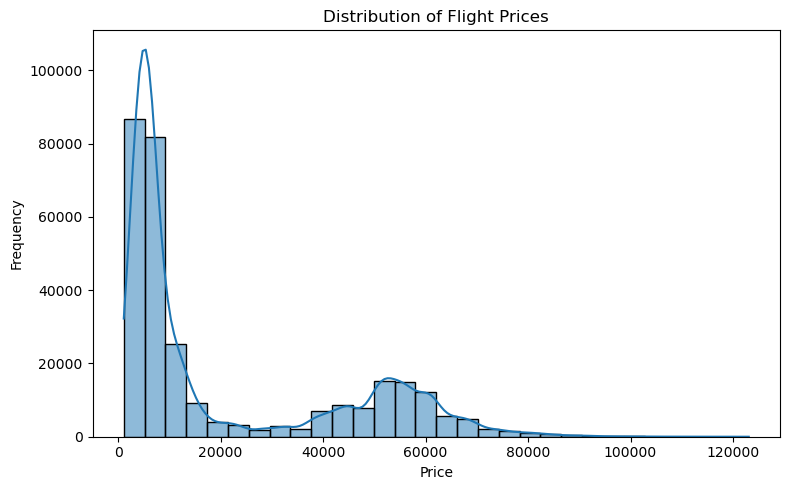

In [49]:
## Understanding distribution of target variable using histogram
plt.figure(figsize=(8,5))
sns.histplot(df['price'], bins=30, kde=True)

plt.title('Distribution of Flight Prices')
plt.xlabel('Price')
plt.ylabel('Frequency')

plt.tight_layout()
plt.show()


In [ ]:
##The histogram shows that the distribution of flight prices is positively (right) skewed, with the majority of flights concentrated in the lower price range. As the ticket price increases, the frequency of flights gradually decreases, indicating that high-priced flights are less common.

##The distribution also exhibits two noticeable peaks, suggesting a bimodal pattern. This may indicate the presence of two distinct groups of ticket prices, which could be influenced by factors such as travel class (e.g., Economy and Business Class), airline, or route.

##In addition, a small number of flights are priced significantly higher than the majority, resulting in a long right tail. These high-priced observations may represent premium fares or long-haul flights and should be further examined during the data preparation stage to determine whether they are valid observations or potential outliers.

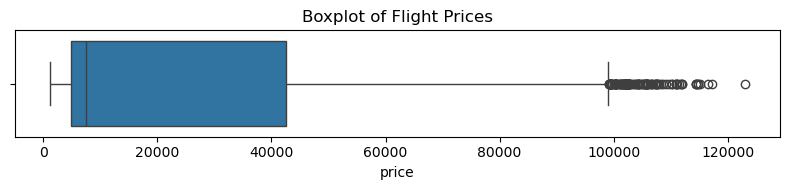

In [51]:
##Uunderstanding the distribution of the target variable using boxplot
plt.figure(figsize=(8,2))
sns.boxplot(x=df['price'])

plt.title('Boxplot of Flight Prices')

plt.tight_layout()
plt.show()

In [ ]:
##The box plot indicates that flight prices exhibit a wide spread, suggesting considerable variability in ticket prices across the dataset. The median price is located closer to the lower quartile, while the upper whisker extends much further than the lower whisker, indicating that the distribution is positively skewed.

##Several observations appear beyond the upper whisker as potential outliers, representing flights with exceptionally high ticket prices. These values may correspond to premium fares or other high-cost flights and should be further evaluated during the data preparation stage to determine whether they are valid observations or require special handling.

##The box plot supports the findings from the histogram by confirming the presence of a right-skewed distribution and a number of high-priced observations.

### 2.3.1.2 Understanding distribution of features

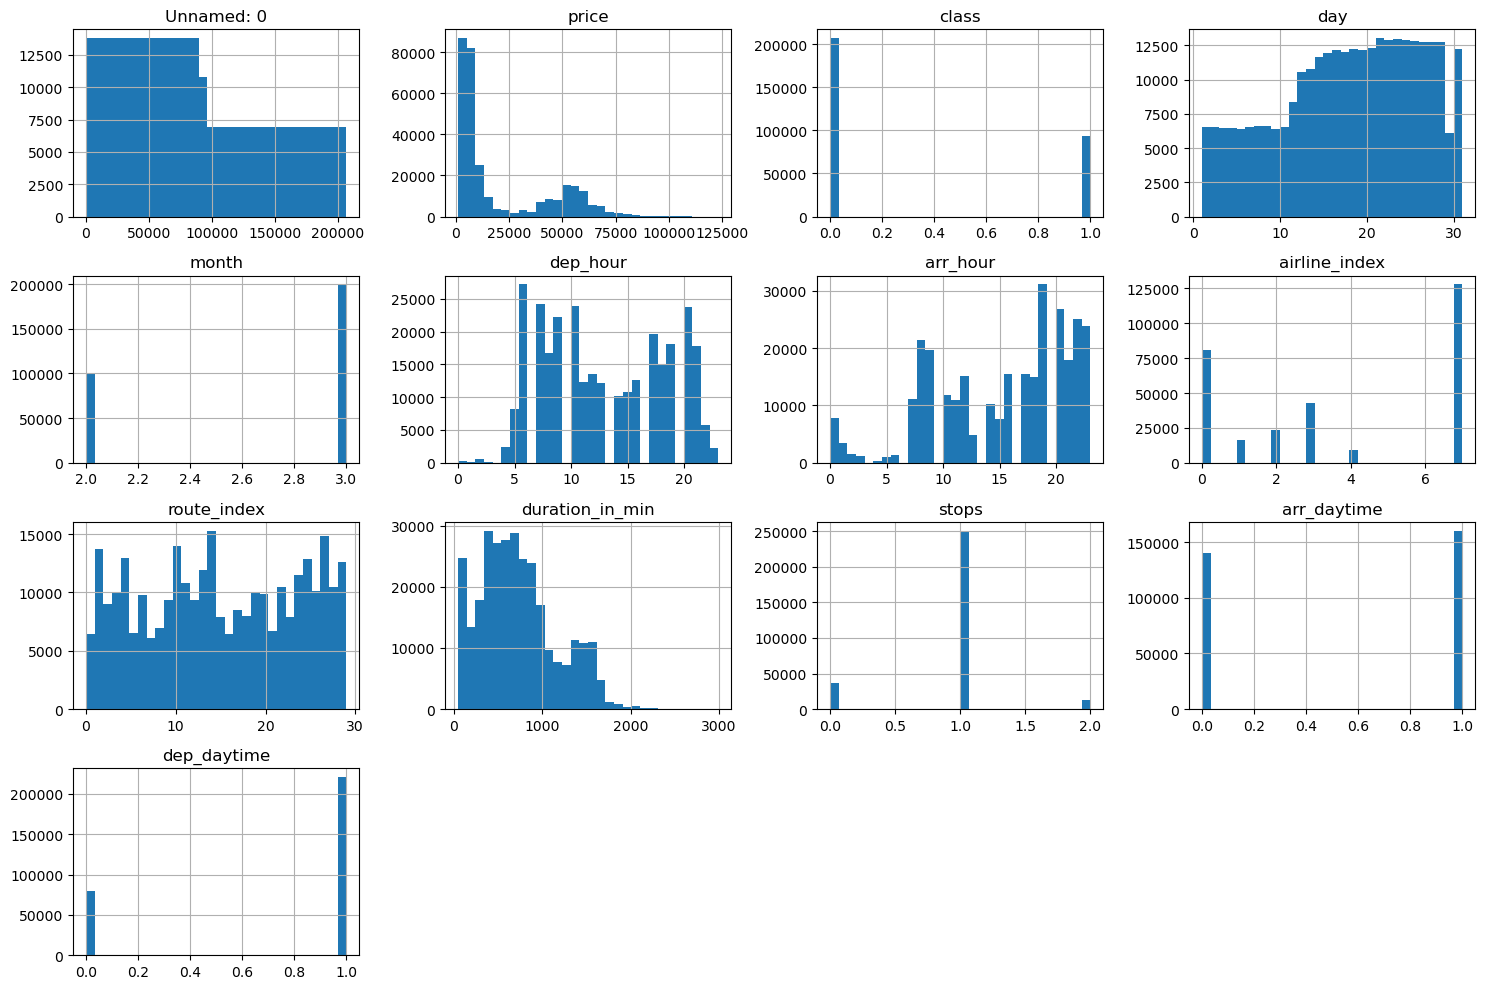

In [ ]:
## Understanding distribution of features - of all numerical features - using histogram
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns

df[numerical_cols].hist(figsize=(15,10), bins=30)

plt.tight_layout()
plt.show()


In [ ]:
##The histograms show that the numerical features exhibit a variety of distribution patterns. Continuous variables such as price and duration_in_min are positively skewed, indicating that most observations are concentrated at lower values while relatively few observations extend into higher ranges. This suggests that higher-priced and longer-duration flights are less common.

##Several numerical features, including class, month, stops, arr_daytime, and dep_daytime, contain only a small number of distinct values. Their histograms display discrete peaks rather than continuous distributions, reflecting that these variables represent encoded categories or binary indicators instead of continuous measurements.

##Features such as day, dep_hour, arr_hour, route_index, and airline_index show observations spread across multiple values. The departure and arrival hour distributions indicate that flights operate throughout the day, while the encoded route and airline indices display varying frequencies across different categories. Overall, the histograms provide an overview of the distribution of each numerical feature and highlight the differences between continuous and discrete variables within the dataset.

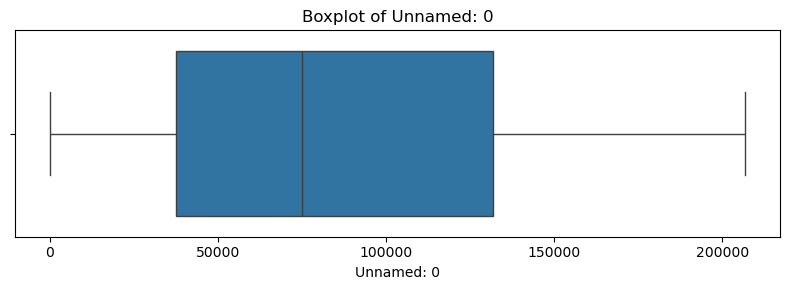

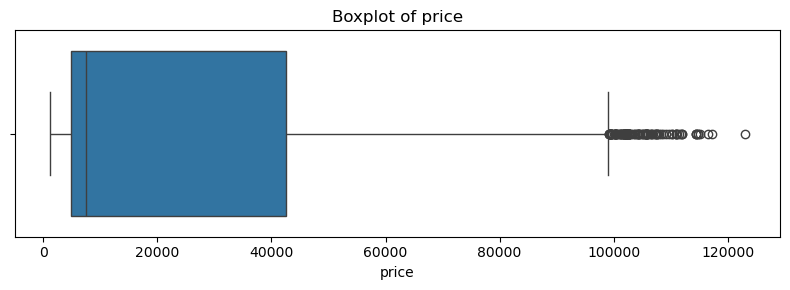

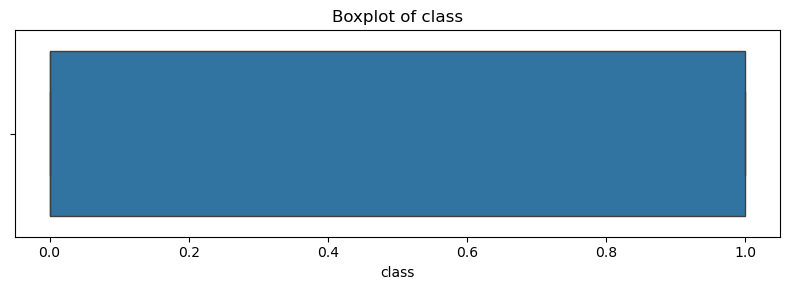

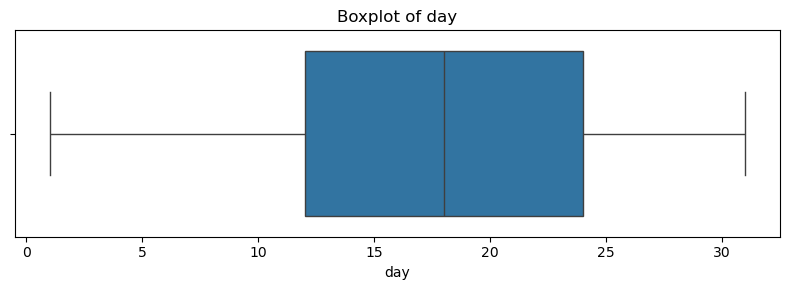

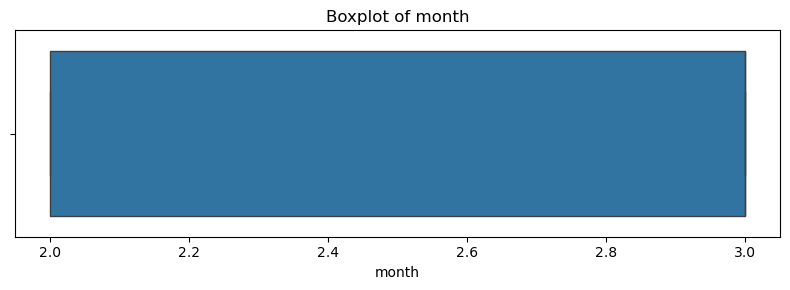

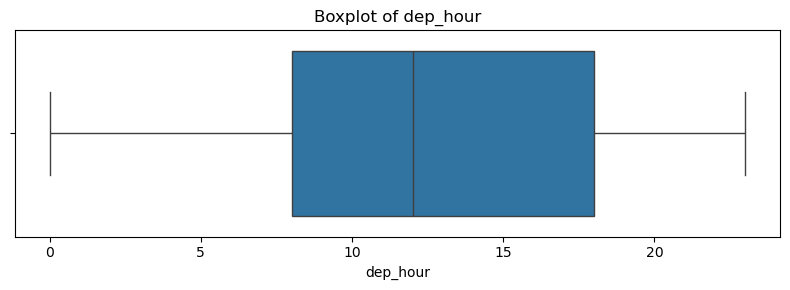

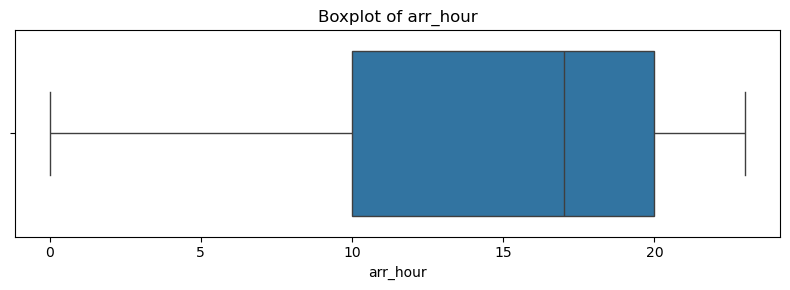

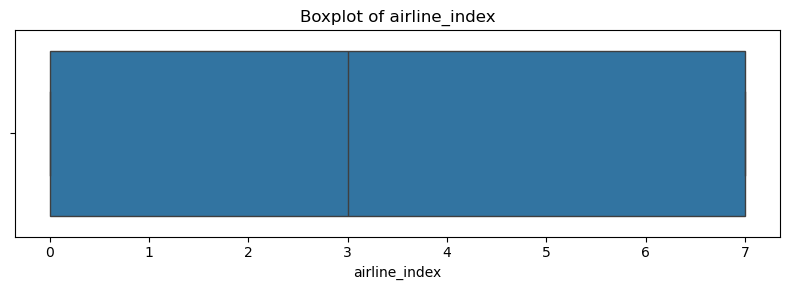

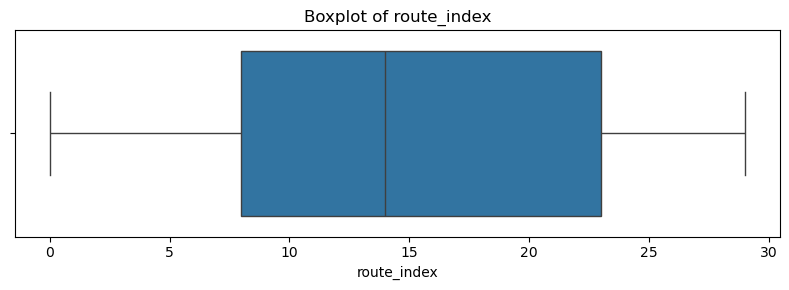

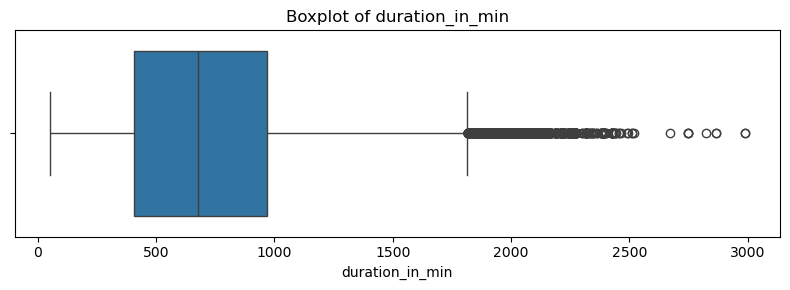

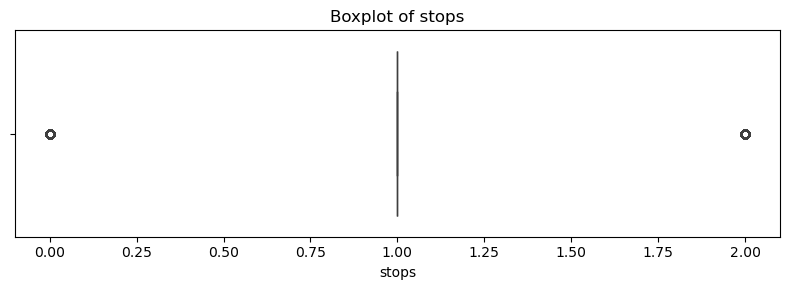

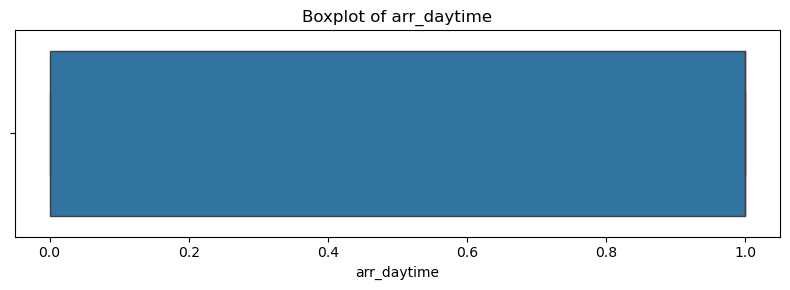

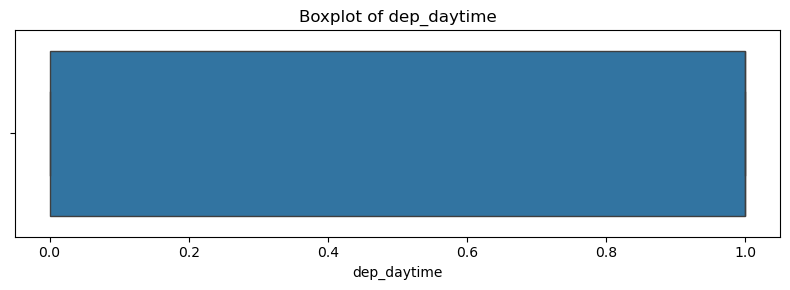

In [52]:
## Understanding distribution of features - of all numerical features - using boxplot
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns

for col in numerical_cols:
    plt.figure(figsize=(8,3))
    sns.boxplot(x=df[col])

    plt.title(f'Boxplot of {col}')

    plt.tight_layout()
    plt.show()

In [ ]:
##I will come back to this later

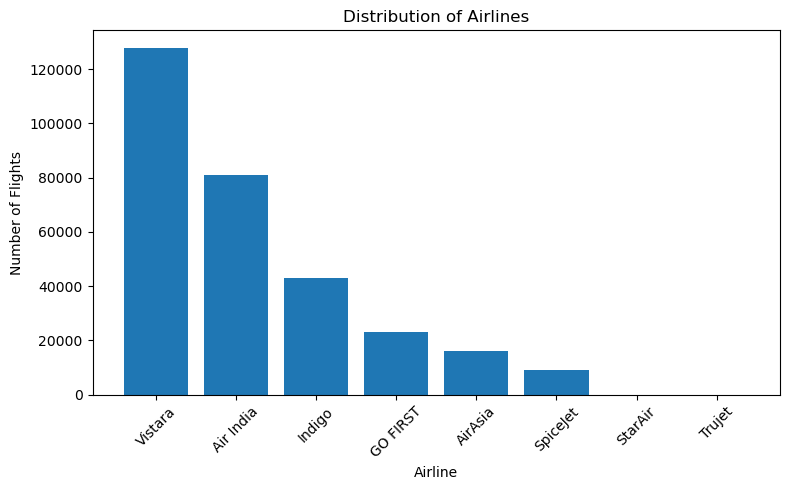

In [38]:
##understanding distribution of features - categorical features - using bar graph - Airline column
airline_counts = df['airline'].value_counts()

plt.figure(figsize=(8,5))
plt.bar(airline_counts.index, airline_counts.values)

plt.title("Distribution of Airlines")
plt.xlabel("Airline")
plt.ylabel("Number of Flights")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [ ]:
##The bar chart shows that the distribution of flights is uneven across different airlines. Vistara has the highest number of flight records in the dataset, followed by Air India and IndiGo, while SpiceJet, StarAir, and Trujet contribute comparatively fewer records.

##The noticeable differences in the number of flights indicate that the dataset is imbalanced with respect to airlines, meaning some airlines are represented much more frequently than others. This variation should be considered during model development, as airlines with a larger number of observations may have a greater influence on the learning process than those with fewer records.

##Overall, the visualization provides an overview of airline representation within the dataset and suggests that flight records are not uniformly distributed across all airlines.

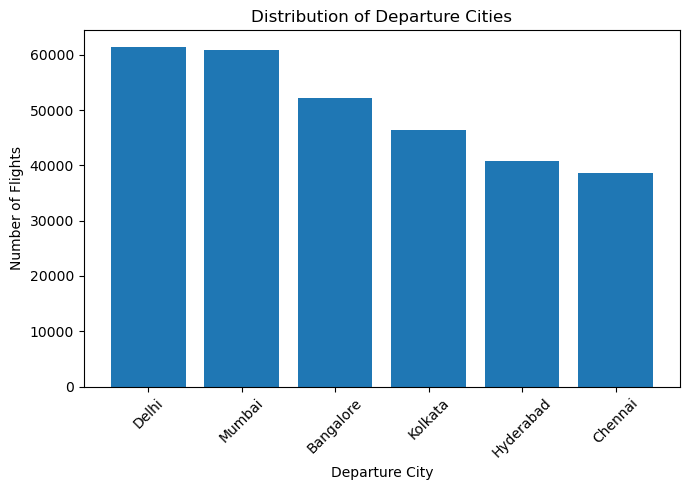

In [39]:
##understanding distribution of features - categorical features - using bar graph - From column
from_counts = df['from'].value_counts()

plt.figure(figsize=(7,5))
plt.bar(from_counts.index, from_counts.values)

plt.title("Distribution of Departure Cities")
plt.xlabel("Departure City")
plt.ylabel("Number of Flights")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [ ]:
##The bar chart shows that the number of flights is distributed across six departure cities, with Delhi and Mumbai having the highest number of flight records in the dataset. Bangalore and Kolkata contribute a moderate number of flights, while Hyderabad and Chennai have comparatively fewer records.

##Although the number of flights varies between cities, the differences are not highly pronounced, indicating that the dataset contains a relatively balanced representation of departure cities. This helps ensure that the model is trained using flight data from multiple locations rather than being heavily dominated by a single departure city.

##Overall, the visualization provides an overview of the distribution of departure cities and suggests that the dataset captures flights originating from several major cities, providing geographical diversity for subsequent analysis and model development.

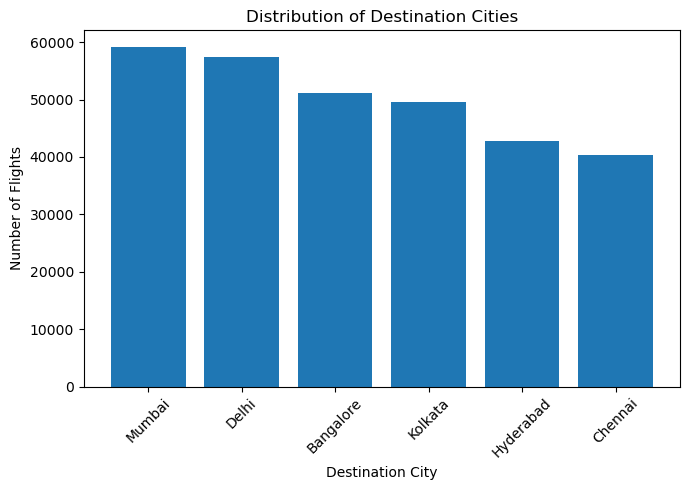

In [40]:
##understanding distribution of features - categorical features - using bar graph - To column
to_counts = df['to'].value_counts()

plt.figure(figsize=(7,5))
plt.bar(to_counts.index, to_counts.values)

plt.title("Distribution of Destination Cities")
plt.xlabel("Destination City")
plt.ylabel("Number of Flights")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [ ]:
##The bar chart shows that flight destinations are distributed across six destination cities, with Mumbai and Delhi having the highest number of flight records in the dataset. Bangalore and Kolkata have a moderate number of flights, while Hyderabad and Chennai appear less frequently as destinations.

##The differences in the number of flights among the destination cities are relatively small, indicating that the dataset provides a fairly balanced representation of destination locations. This balanced distribution helps ensure that the model is exposed to flights arriving at multiple cities rather than being dominated by a single destination.

##Overall, the visualization demonstrates that the dataset contains flight records across several major destination cities, providing good geographical coverage for further exploratory analysis and predictive modelling.

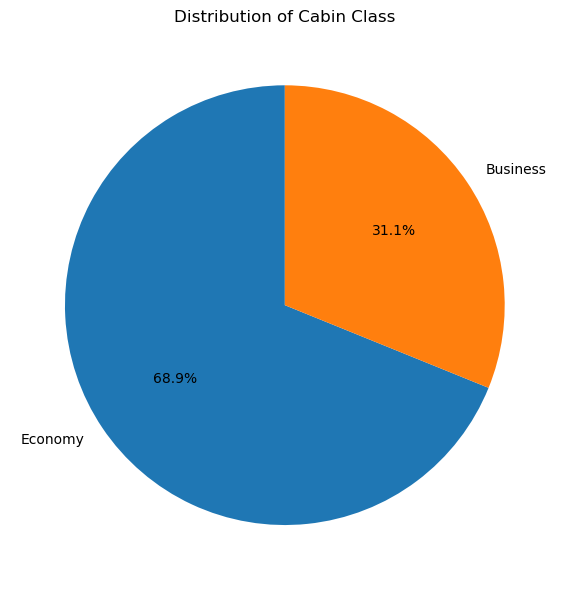

In [41]:
##understanding distribution of features - categorical features - using pie chart - Class Category column
class_counts = df['class_category'].value_counts()

plt.figure(figsize=(6,6))
plt.pie(class_counts.values,
        labels=class_counts.index,
        autopct='%1.1f%%',
        startangle=90)

plt.title("Distribution of Cabin Class")
plt.tight_layout()
plt.show()

In [ ]:
##The pie chart shows that Economy Class accounts for the majority of flight records in the dataset, representing approximately 68.9% of all observations, while Business Class makes up the remaining 31.1%. This indicates that Economy Class flights are more than twice as common as Business Class flights within the dataset.

##The unequal distribution suggests that the dataset is moderately imbalanced with respect to cabin class. As a result, the machine learning model will be trained on a larger proportion of Economy Class flights, which should be considered when interpreting model performance across different ticket classes.

##Overall, the visualization provides a clear overview of the cabin class composition of the dataset and reflects the greater representation of Economy Class flights compared to Business Class flights.

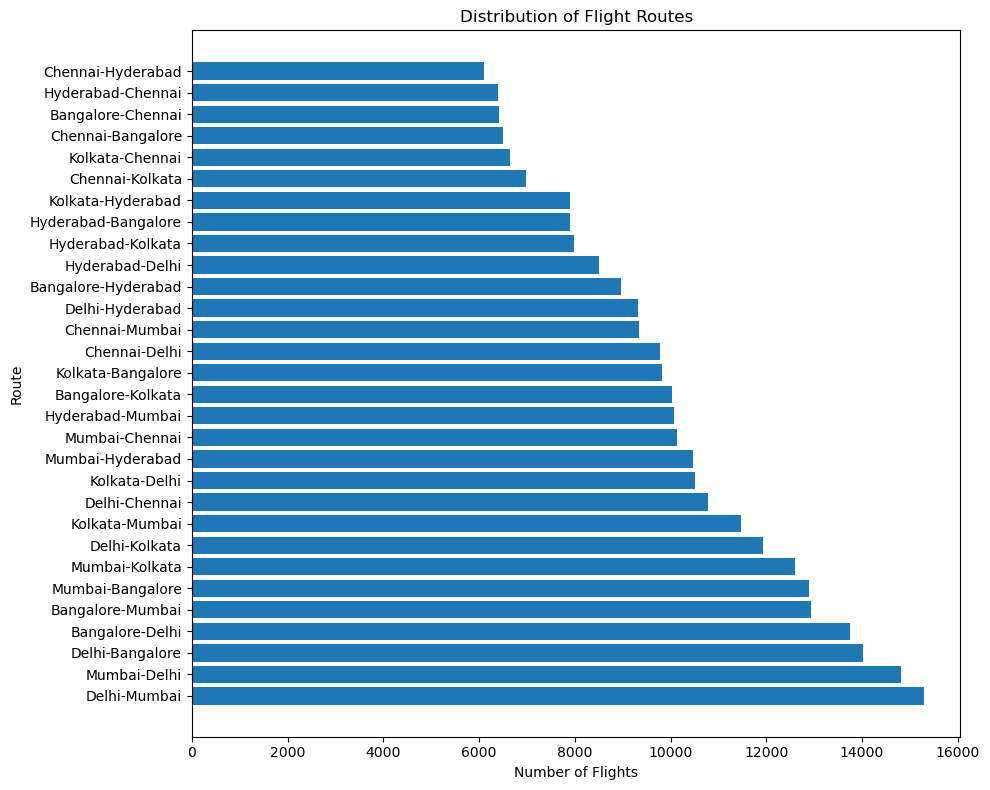

In [42]:
##understanding distribution of features - categorical features - using bar graph - Route column
route_counts = df['route'].value_counts()

plt.figure(figsize=(10,8))
plt.barh(route_counts.index, route_counts.values)

plt.title("Distribution of Flight Routes")
plt.xlabel("Number of Flights")
plt.ylabel("Route")
plt.tight_layout()
plt.show()

In [ ]:
##The horizontal bar chart shows that the dataset contains flight records across 30 different routes, with the number of records varying from one route to another. Delhi–Mumbai, Mumbai–Delhi, and Delhi–Bangalore are among the most frequently represented routes, while routes such as Chennai–Hyderabad and Hyderabad–Chennai have comparatively fewer flight records.

##Although some routes contain more observations than others, the differences are moderate rather than extreme, indicating that the dataset provides a reasonably balanced representation of multiple flight routes. This diversity allows the machine learning model to learn from flights operating across different city pairs instead of relying heavily on a small number of routes.

##Overall, the visualization demonstrates that the dataset covers a wide range of domestic flight routes, providing sufficient route diversity for exploratory analysis and predictive modelling.

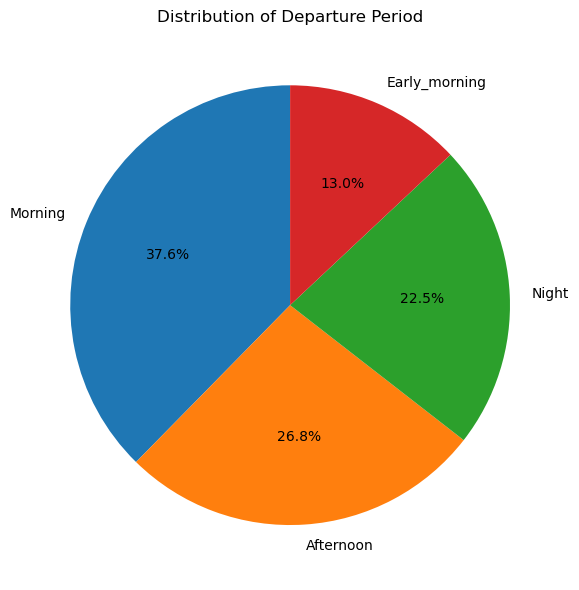

In [43]:
##understanding distribution of features - categorical features - using pie chart - Departure Period column
dep_period_counts = df['dep_period'].value_counts()

plt.figure(figsize=(6,6))
plt.pie(dep_period_counts.values,
        labels=dep_period_counts.index,
        autopct='%1.1f%%',
        startangle=90)

plt.title("Distribution of Departure Period")
plt.tight_layout()
plt.show()

In [ ]:
##The pie chart shows that flight records are distributed across four departure periods, with Morning accounting for the largest proportion of the dataset at 37.6%. This is followed by Afternoon (26.8%), Night (22.5%), while Early Morning has the smallest proportion at 13.0%.

##The distribution indicates that departure times are not evenly represented, with a greater proportion of flight records occurring during the morning and afternoon periods. Despite this imbalance, all four departure periods are represented in the dataset, allowing the machine learning model to learn from flights operating at different times of the day.

##Overall, the visualization provides an overview of the temporal distribution of departure periods and suggests that flight records are concentrated in the morning, with comparatively fewer departures scheduled during the early morning period.

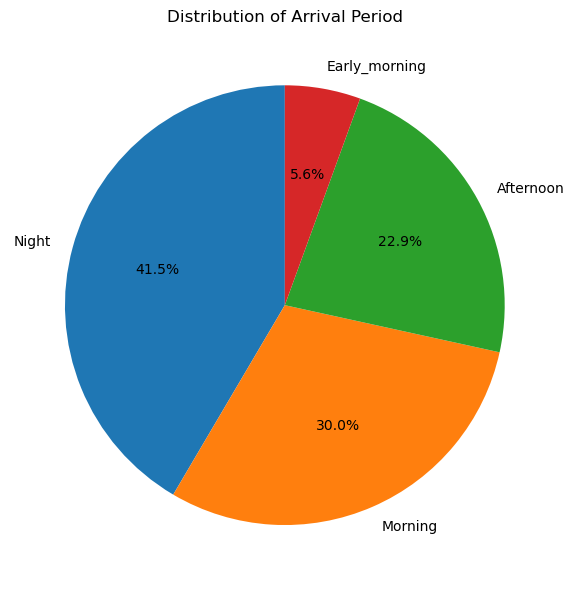

In [44]:
##understanding distribution of features - categorical features - using pie chart - Arrival period column
arr_period_counts = df['arr_period'].value_counts()

plt.figure(figsize=(6,6))
plt.pie(arr_period_counts.values,
        labels=arr_period_counts.index,
        autopct='%1.1f%%',
        startangle=90)

plt.title("Distribution of Arrival Period")
plt.tight_layout()
plt.show()

In [ ]:
##The pie chart shows that flight records are distributed across four arrival periods, with Night accounting for the largest proportion of the dataset at 41.5%. This is followed by Morning (30.0%) and Afternoon (22.9%), while Early Morning represents the smallest proportion at 5.6%.

##The distribution indicates that arrival periods are unevenly represented, with a substantial proportion of flights arriving during the night. In contrast, relatively few flight records are associated with early morning arrivals. Nevertheless, all four arrival periods are represented, allowing the machine learning model to learn from flights arriving at different times of the day.

##Overall, the visualization provides an overview of the temporal distribution of arrival periods and highlights that flight records are predominantly concentrated in the night period, while early morning arrivals occur less frequently within the dataset.

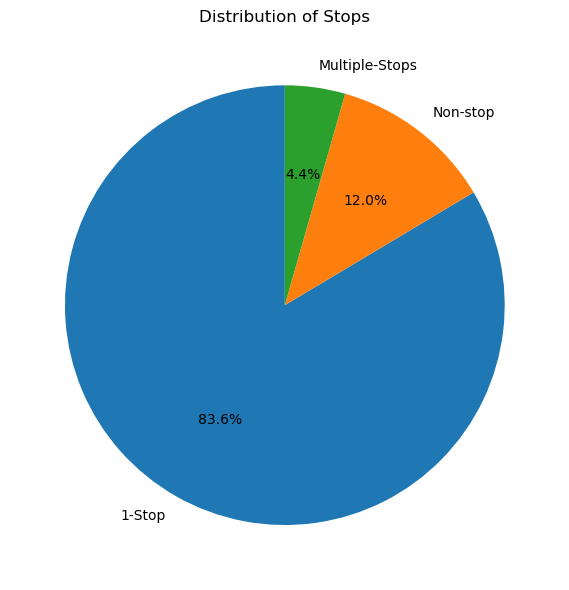

In [45]:
##understanding distribution of features - categorical features - using pie chart - stops cateogry column
stops_counts = df['stops_category'].value_counts()

plt.figure(figsize=(6,6))
plt.pie(stops_counts.values,
        labels=stops_counts.index,
        autopct='%1.1f%%',
        startangle=90)

plt.title("Distribution of Stops")
plt.tight_layout()
plt.show()

In [ ]:
##The pie chart shows that 1-Stop flights account for the vast majority of flight records in the dataset, representing approximately 83.6% of all observations. In comparison, Non-stop flights make up 12.0%, while Multiple-Stops flights account for only 4.4% of the dataset.

##The distribution is highly imbalanced, with one-stop flights being significantly more prevalent than the other stop categories. As a result, the machine learning model will be trained primarily on one-stop flight records, while comparatively fewer observations are available for non-stop and multiple-stop flights.

##Overall, the visualization highlights that the dataset is dominated by one-stop flights, with non-stop and multiple-stop flights forming a much smaller proportion of the available flight records.

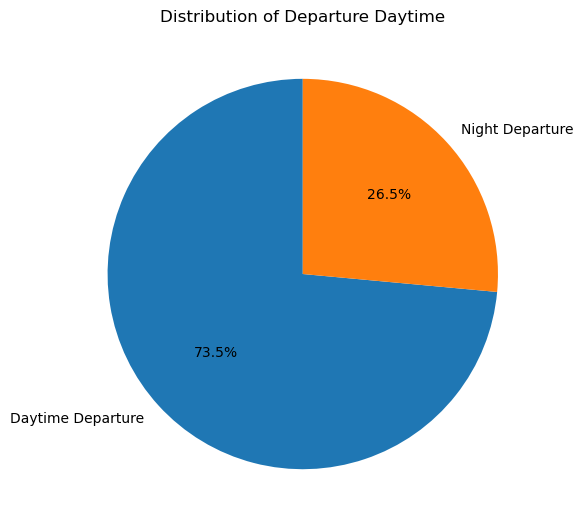

In [46]:
##understanding distribution of features - categorical features - using pie chart - departure daytime category column
dep_day_counts = df['dep_daytime_category'].value_counts()

plt.figure(figsize=(6,6))
plt.pie(dep_day_counts.values,
        labels=dep_day_counts.index,
        autopct='%1.1f%%',
        startangle=90)

plt.title("Distribution of Departure Daytime")
plt.tight_layout()
plt.show()

In [ ]:
##The pie chart shows that Daytime Departure accounts for the majority of flight records in the dataset, representing approximately 73.5% of all observations, while Night Departure constitutes the remaining 26.5%.

##The distribution is moderately imbalanced, indicating that a substantially larger proportion of flights in the dataset depart during the daytime than at night. Nevertheless, both departure categories are sufficiently represented, allowing the machine learning model to learn patterns associated with both daytime and night departures.

##Overall, the visualization provides a clear overview of the departure time composition of the dataset and highlights that daytime departures are considerably more common than night departures.

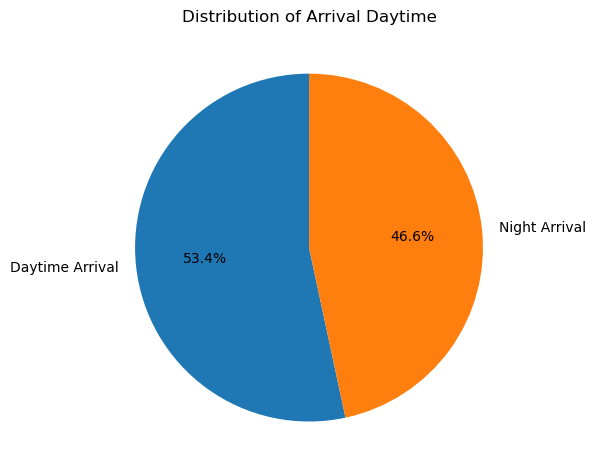

In [47]:
##understanding distribution of features - categorical features - using pie chart - arrival daytime category column
arr_day_counts = df['arr_daytime_category'].value_counts()

plt.figure(figsize=(6,6))
plt.pie(arr_day_counts.values,
        labels=arr_day_counts.index,
        autopct='%1.1f%%',
        startangle=90)

plt.title("Distribution of Arrival Daytime")
plt.tight_layout()
plt.show()

In [ ]:
##The pie chart shows that Daytime Arrival accounts for 53.4% of the flight records in the dataset, while Night Arrival represents 46.6%. The relatively small difference between the two categories indicates that flights arrive during both daytime and nighttime in nearly equal proportions.

##Compared with the departure daytime distribution, the arrival daytime distribution is more balanced, providing a more even representation of both arrival categories. This balanced distribution enables the machine learning model to learn patterns associated with both daytime and nighttime arrivals without being heavily influenced by one category.

##Overall, the visualization illustrates that the dataset contains a well-balanced mix of daytime and nighttime arrival records, contributing to a more comprehensive representation of flight arrival times.

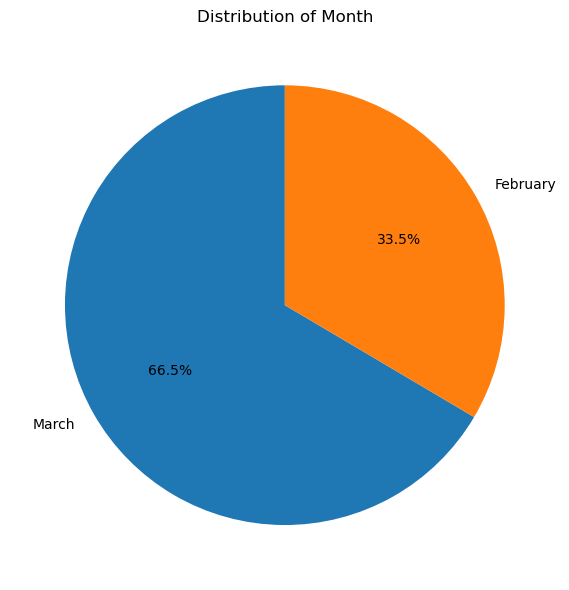

In [48]:
##understanding distribution of features - categorical features - using pie chart - month category column
month_counts = df['month_category'].value_counts()

plt.figure(figsize=(6,6))
plt.pie(month_counts.values,
        labels=month_counts.index,
        autopct='%1.1f%%',
        startangle=90)

plt.title("Distribution of Month")
plt.tight_layout()
plt.show()

In [ ]:
##The pie chart shows that the dataset contains flight records from two months, with March accounting for the majority of observations at 66.5%, while February contributes the remaining 33.5%.

##The distribution is moderately imbalanced, indicating that a larger proportion of flight records was collected in March compared to February. As a result, the machine learning model will be trained on more observations from March, although both months remain sufficiently represented for analysis.

##Overall, the visualization provides an overview of the temporal coverage of the dataset and shows that the flight records are concentrated in March, with a smaller but substantial proportion originating from February.

In [ ]:
##Flight Number

##The flight_no column contains 1,569 unique flight numbers, making it behave 
# as an identifier rather than a meaningful categorical feature. 
# Visualizing this column would produce a cluttered and uninformative chart. 
# Therefore, it is excluded from the 
# EDA visualizations and will be removed during the data preparation stage.

### 2.3.2 Understanding relationship between variables

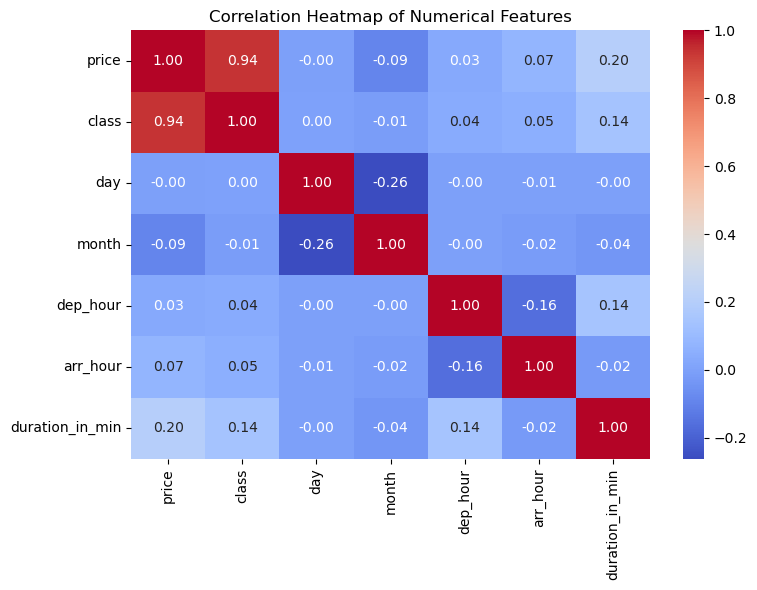

In [70]:
# Select meaningful numerical features for correlation analysis

heatmap_features = [
    'price',
    'class',
    'day',
    'month',
    'dep_hour',
    'arr_hour',
    'duration_in_min'
]

corr = df[heatmap_features].corr()

plt.figure(figsize=(8, 6))

sns.heatmap(
    corr,
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title("Correlation Heatmap of Numerical Features")

plt.tight_layout()
plt.show()

In [ ]:
##The correlation heatmap illustrates the strength and direction of the linear relationships between the numerical features in the dataset. Overall, most feature pairs exhibit weak to moderate correlations, indicating that the numerical variables are largely independent and are unlikely to introduce significant multicollinearity into the machine learning model.

##Among all variables, class shows the strongest positive correlation with price (r = 0.94), suggesting that cabin class has a substantial influence on flight prices. Moderate positive correlations are also observed between airline_index and price (r = 0.24), as well as duration_in_min and price (r = 0.20), indicating that these features may also contribute to price prediction, although their relationships are considerably weaker.

##The heatmap also reveals a moderate positive correlation between duration_in_min and stops (r = 0.47), suggesting that flights with more stops generally tend to have longer travel durations. In contrast, dep_hour and dep_daytime (r = -0.55), as well as arr_hour and arr_daytime (r = -0.53), exhibit moderate negative correlations, reflecting the relationship between the continuous hour variables and their corresponding daytime indicator variables.

##Overall, the correlation analysis indicates that while most numerical features have relatively weak linear relationships with one another, several features demonstrate meaningful associations with the target variable (price) and may serve as important predictors during model development.

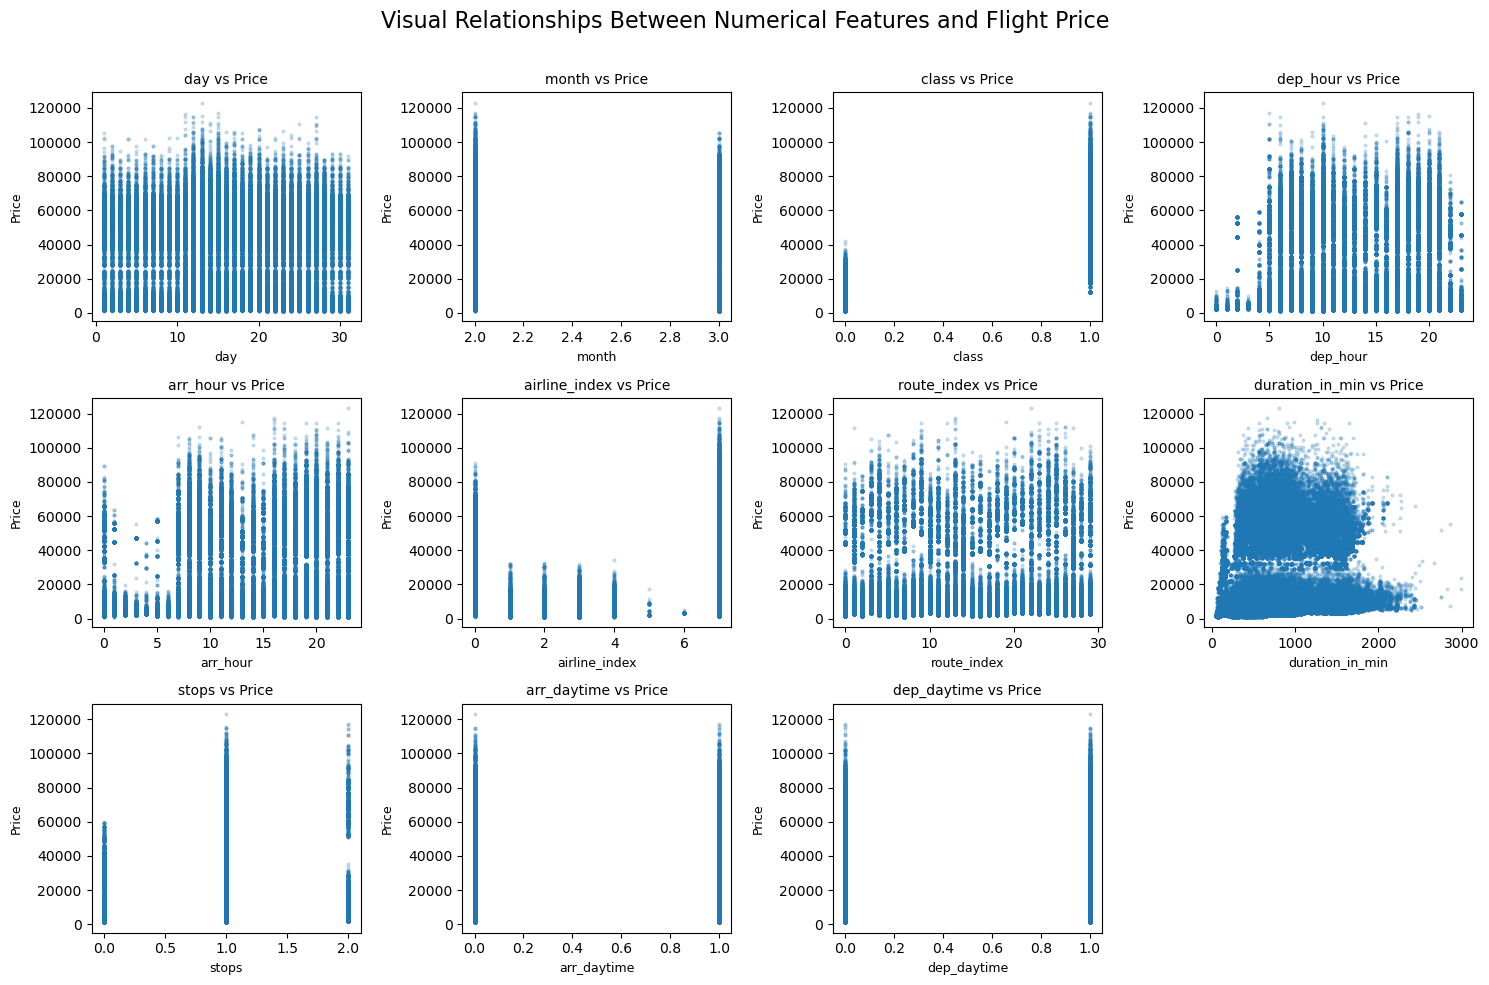

In [74]:
# Numerical features to compare with price
numerical_features = [
    'day',
    'month',
    'class',
    'dep_hour',
    'arr_hour',
    'airline_index',
    'route_index',
    'duration_in_min',
    'stops',
    'arr_daytime',
    'dep_daytime'
]

fig, axes = plt.subplots(3, 4, figsize=(15, 10))
axes = axes.flatten()

for i, feature in enumerate(numerical_features):

    axes[i].scatter(
        df[feature],
        df['price'],
        alpha=0.2,
        s=4
    )

    axes[i].set_title(f'{feature} vs Price', fontsize=10)
    axes[i].set_xlabel(feature, fontsize=9)
    axes[i].set_ylabel('Price', fontsize=9)

# Remove the unused subplot
fig.delaxes(axes[-1])

plt.suptitle(
    'Visual Relationships Between Numerical Features and Flight Price',
    fontsize=16
)

plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()

In [ ]:
##The scatter plots illustrate the relationships between the numerical features and the target variable (price). Overall, the strength of these relationships varies across the features, with some variables showing noticeable trends while others exhibit little or no clear association with flight prices.

##Among the numerical features, class demonstrates the strongest relationship with price, where Business Class flights consistently occupy a higher price range than Economy Class flights. duration_in_min also exhibits a moderate positive relationship with price, suggesting that longer-duration flights generally tend to have higher ticket prices, although considerable variability exists. Similarly, airline_index shows some variation in ticket prices across different airlines, indicating that airline choice may influence flight pricing.

##In contrast, features such as day, month, dep_hour, arr_hour, route_index, stops, arr_daytime, and dep_daytime do not display strong linear relationships with price. While certain categories or values exhibit differences in price ranges, the observations remain widely scattered, suggesting that these variables alone are insufficient to explain variations in flight prices.

##Overall, the scatter plots indicate that cabin class and flight duration appear to be the most influential numerical features associated with ticket price, whereas the remaining numerical variables demonstrate weaker individual relationships and may contribute more effectively when combined with other features during model development.

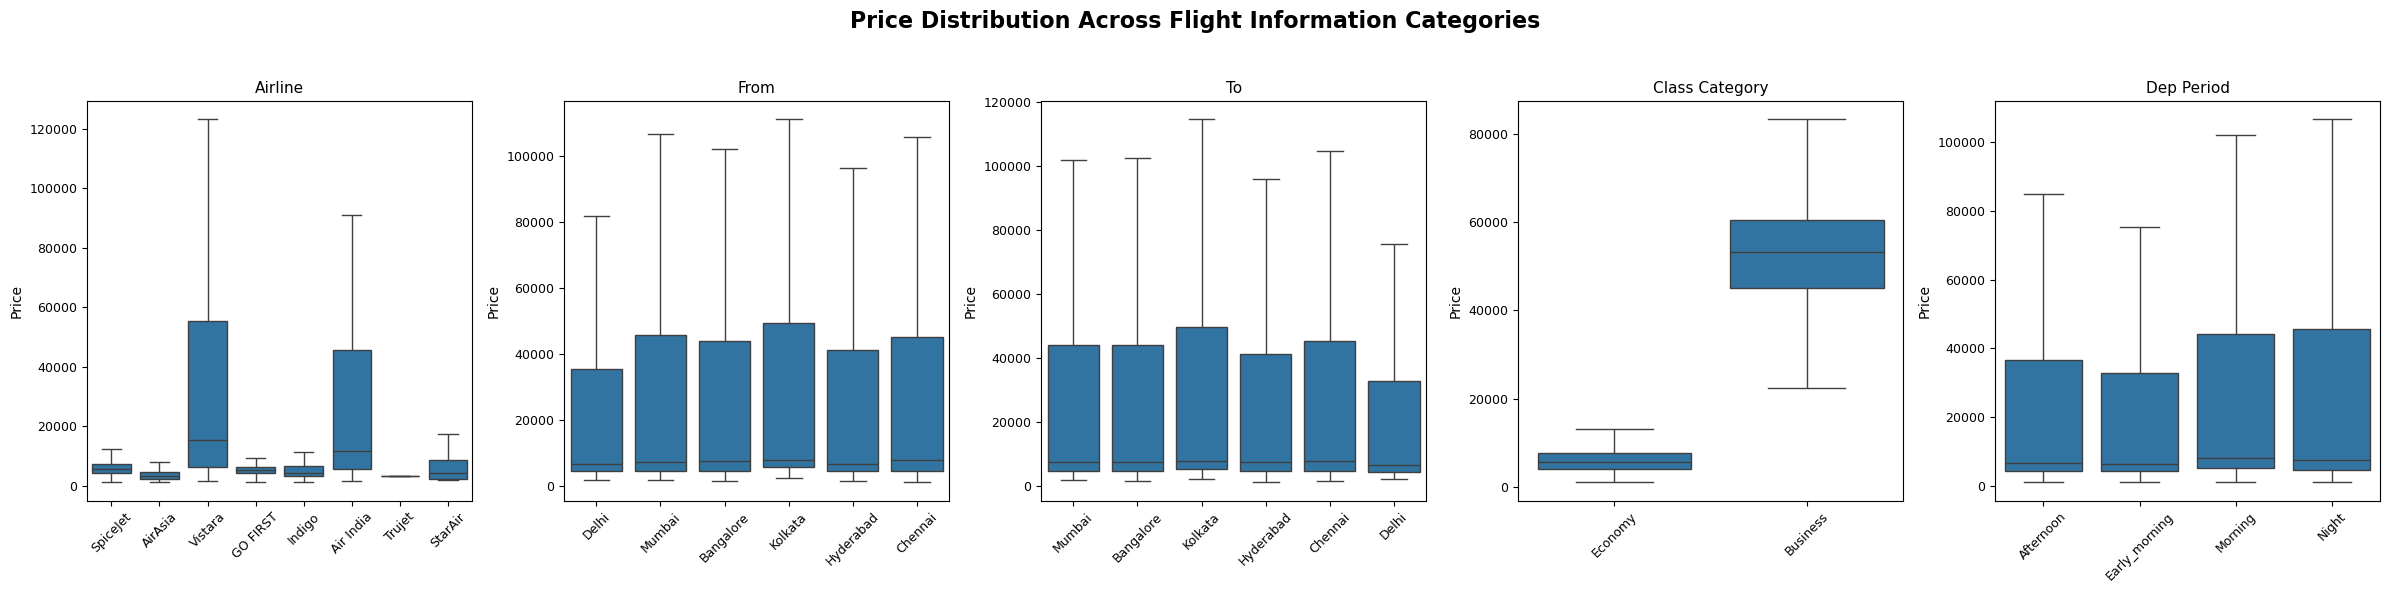

In [79]:
# Categorical features to compare with price - all categorical columns except for route
categorical_features_1 = [
    'airline',
    'from',
    'to',
    'class_category',
    'dep_period'
]

fig, axes = plt.subplots(1, 5, figsize=(24, 6))
axes = axes.flatten()

for i, feature in enumerate(categorical_features_1):

    sns.boxplot(
        data=df,
        x=feature,
        y='price',
        ax=axes[i],
        showfliers=False
    )

    axes[i].set_title(feature.replace('_', ' ').title(), fontsize=11)
    axes[i].set_xlabel("")
    axes[i].set_ylabel("Price", fontsize=10)

    axes[i].tick_params(axis='x', rotation=45, labelsize=9)
    axes[i].tick_params(axis='y', labelsize=9)

plt.suptitle(
    "Price Distribution Across Flight Information Categories",
    fontsize=16,
    fontweight='bold'
)

plt.tight_layout(rect=[0, 0, 1, 0.95])

plt.show()

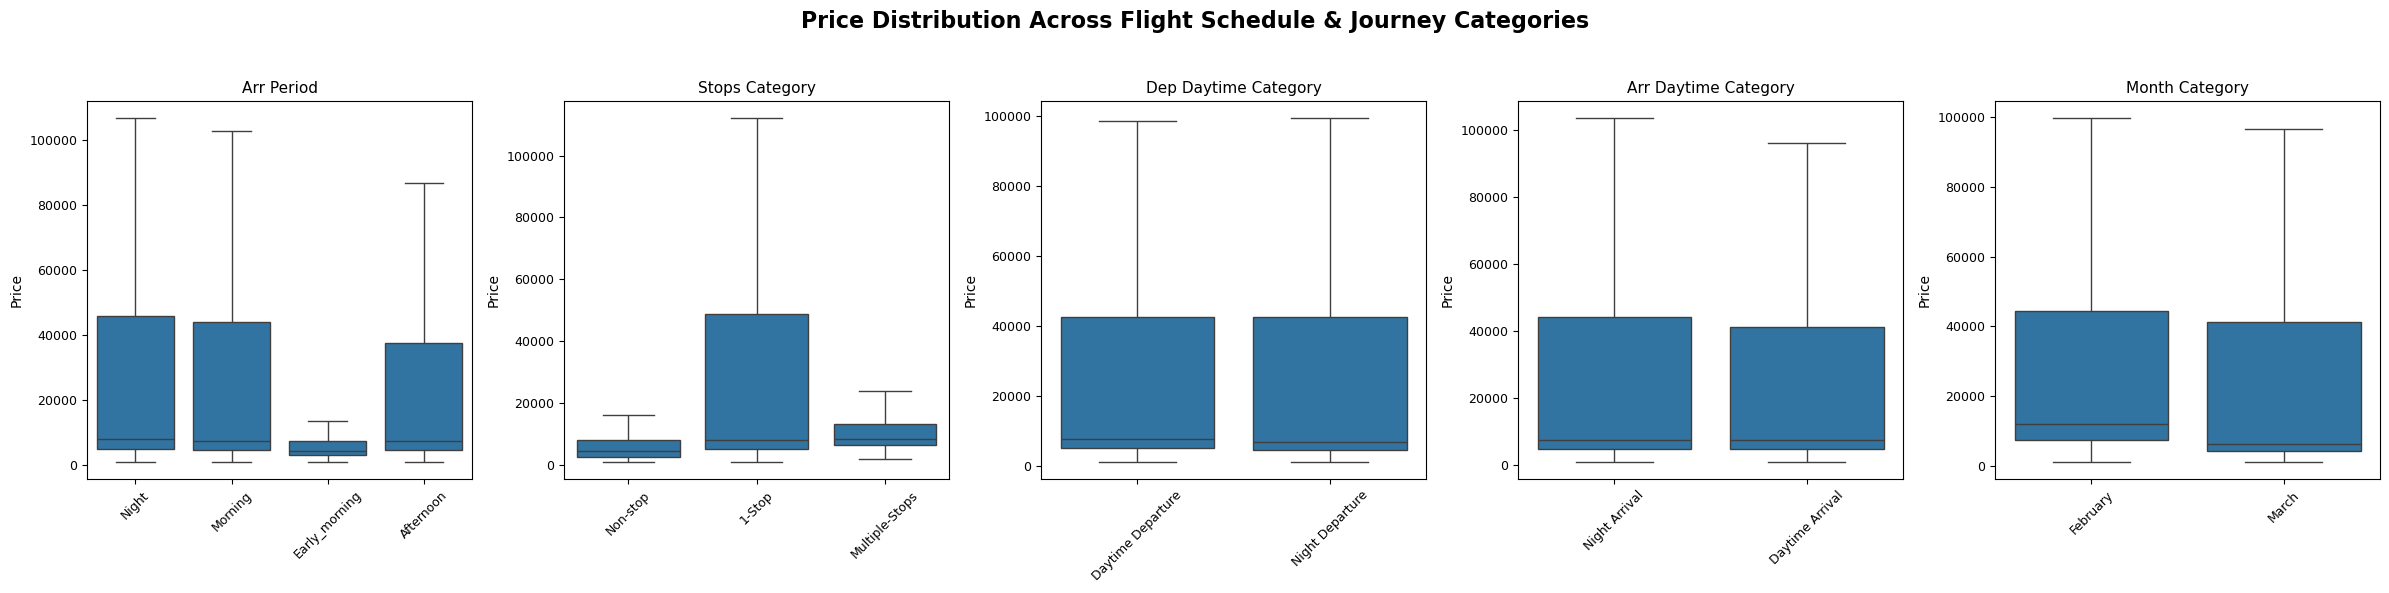

In [80]:
## Categorical features to compare with price - all categorical columns except for route
categorical_features_2 = [
    'arr_period',
    'stops_category',
    'dep_daytime_category',
    'arr_daytime_category',
    'month_category'
]

fig, axes = plt.subplots(1, 5, figsize=(24, 6))
axes = axes.flatten()

for i, feature in enumerate(categorical_features_2):

    sns.boxplot(
        data=df,
        x=feature,
        y='price',
        ax=axes[i],
        showfliers=False
    )

    axes[i].set_title(feature.replace('_', ' ').title(), fontsize=11)
    axes[i].set_xlabel("")
    axes[i].set_ylabel("Price", fontsize=10)

    axes[i].tick_params(axis='x', rotation=45, labelsize=9)
    axes[i].tick_params(axis='y', labelsize=9)

plt.suptitle(
    "Price Distribution Across Flight Schedule & Journey Categories",
    fontsize=16,
    fontweight='bold'
)

plt.tight_layout(rect=[0, 0, 1, 0.95])

plt.show()

In [ ]:
##The box plots illustrate how the distribution of flight prices varies across different categorical features. Among all variables, class_category exhibits the most pronounced difference in ticket prices, with Business Class showing a substantially higher median price and a wider price range than Economy Class. This indicates that cabin class is one of the strongest factors influencing flight prices.

##Several categorical features, including airline, from, to, dep_period, arr_period, and stops_category, also display noticeable differences in price distributions across their respective categories. Variations in median prices and interquartile ranges suggest that factors such as airline, departure city, destination city, departure and arrival periods, and the number of stops may contribute to differences in ticket prices. However, the degree of influence appears less substantial than that observed for cabin class.

##In contrast, arr_daytime_category, dep_daytime_category, and month_category exhibit relatively similar price distributions across their categories. The considerable overlap between the box plots indicates that these variables alone have a weaker association with flight prices and are less likely to be strong individual predictors.

##Overall, the box plot analysis suggests that cabin class, together with operational factors such as airline, route, departure and arrival periods, and stop category, demonstrates greater variation in ticket prices, whereas broader time-based categories show comparatively smaller differences.

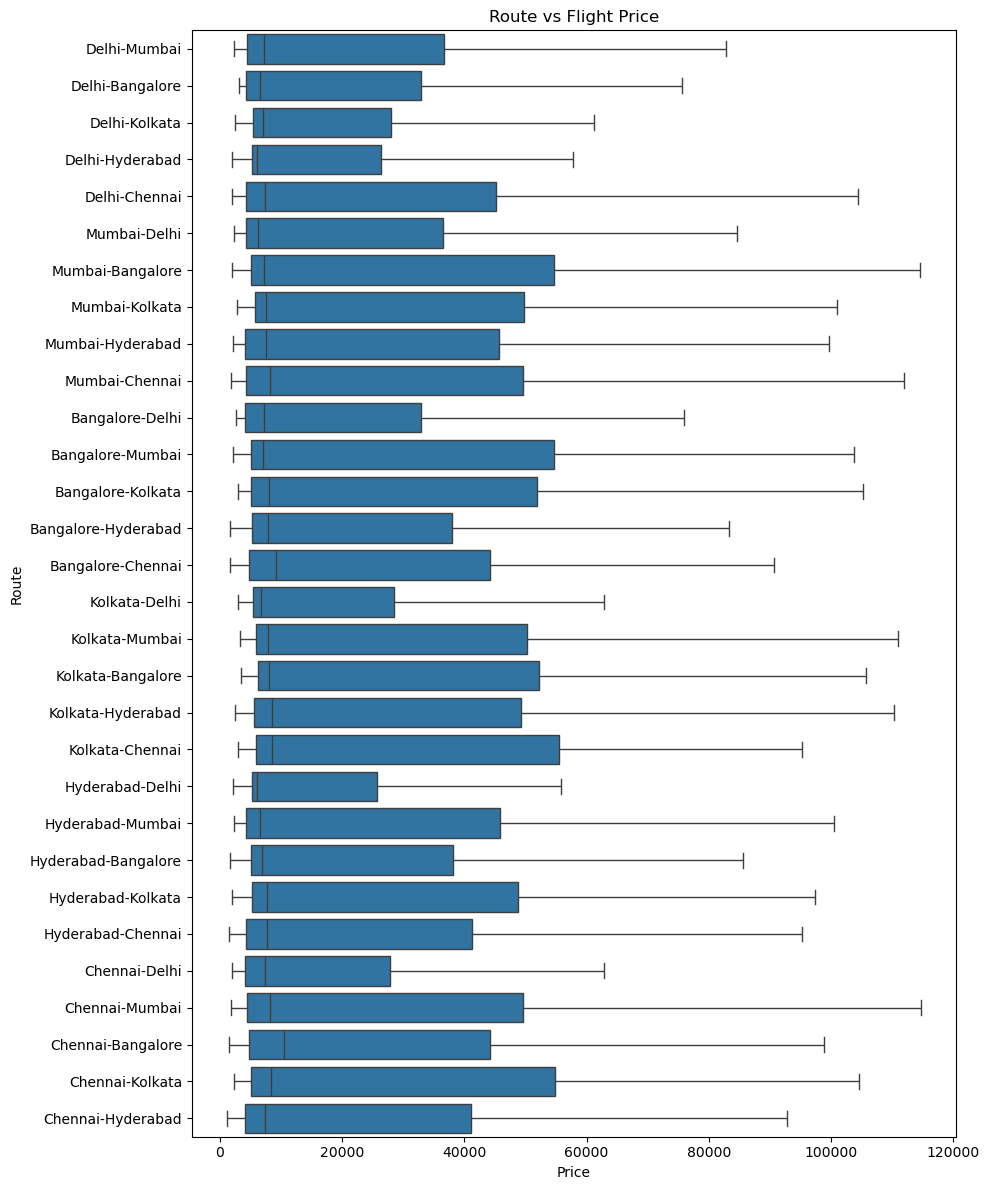

In [60]:
# Categorical features to compare with price - route column
plt.figure(figsize=(10, 12))

sns.boxplot(
    data=df,
    y='route',
    x='price',
    showfliers=False
)

plt.title('Route vs Flight Price')
plt.xlabel('Price')
plt.ylabel('Route')

plt.tight_layout()
plt.show()

In [ ]:
##The box plot illustrates the distribution of flight prices across the 30 flight routes in the dataset. Overall, the price distributions vary noticeably between routes, indicating that the origin–destination pair is associated with differences in ticket prices. While some routes exhibit higher price ranges and greater variability, others show comparatively lower and more consistent pricing patterns.

##Despite these differences, there is considerable overlap in the price distributions across many routes. This suggests that although the flight route influences ticket prices, it is unlikely to be the sole determining factor. Other variables, such as cabin class, airline, flight duration, and the number of stops, may also contribute to the observed variation in prices.

##Overall, the visualization indicates that flight route is an informative feature for price prediction, as different routes demonstrate distinct pricing characteristics while sharing some common price ranges.

# 3. Data Preparation

## 3.1 Data Cleaning

In [4]:
##remove the "Unnamed: 0" column
df.drop(columns=['Unnamed: 0'], inplace=True)

In [5]:
df.columns

Index(['airline', 'from', 'to', 'price', 'class_category', 'class', 'day',
       'month', 'flight_no', 'route', 'dep_hour', 'arr_hour', 'dep_period',
       'arr_period', 'airline_index', 'route_index', 'duration_in_min',
       'stops', 'stops_category', 'arr_daytime', 'arr_daytime_category',
       'dep_daytime', 'dep_daytime_category', 'month_category'],
      dtype='object')

In [6]:
##removed the "flight_no" column
df.drop(columns=['flight_no'], inplace=True)

In [7]:
df.columns

Index(['airline', 'from', 'to', 'price', 'class_category', 'class', 'day',
       'month', 'route', 'dep_hour', 'arr_hour', 'dep_period', 'arr_period',
       'airline_index', 'route_index', 'duration_in_min', 'stops',
       'stops_category', 'arr_daytime', 'arr_daytime_category', 'dep_daytime',
       'dep_daytime_category', 'month_category'],
      dtype='object')

In [8]:
##check for missing values in each column
df.isnull().sum().sum()

np.int64(0)

In [9]:
##check for missing values using info()
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300257 entries, 0 to 300256
Data columns (total 23 columns):
 #   Column                Non-Null Count   Dtype 
---  ------                --------------   ----- 
 0   airline               300257 non-null  object
 1   from                  300257 non-null  object
 2   to                    300257 non-null  object
 3   price                 300257 non-null  int64 
 4   class_category        300257 non-null  object
 5   class                 300257 non-null  int64 
 6   day                   300257 non-null  int64 
 7   month                 300257 non-null  int64 
 8   route                 300257 non-null  object
 9   dep_hour              300257 non-null  int64 
 10  arr_hour              300257 non-null  int64 
 11  dep_period            300257 non-null  object
 12  arr_period            300257 non-null  object
 13  airline_index         300257 non-null  int64 
 14  route_index           300257 non-null  int64 
 15  duration_in_min  

In [10]:
##count and check for duplicate rows
df.duplicated().sum()

np.int64(262)

In [11]:
##remove duplicate rows
df.drop_duplicates(inplace=True)


In [12]:
##verify they were removed
df.duplicated().sum()

np.int64(0)

In [13]:
##check the new dataset size
df.shape

(299995, 23)

In [14]:
##verify Data Types 
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 299995 entries, 0 to 300256
Data columns (total 23 columns):
 #   Column                Non-Null Count   Dtype 
---  ------                --------------   ----- 
 0   airline               299995 non-null  object
 1   from                  299995 non-null  object
 2   to                    299995 non-null  object
 3   price                 299995 non-null  int64 
 4   class_category        299995 non-null  object
 5   class                 299995 non-null  int64 
 6   day                   299995 non-null  int64 
 7   month                 299995 non-null  int64 
 8   route                 299995 non-null  object
 9   dep_hour              299995 non-null  int64 
 10  arr_hour              299995 non-null  int64 
 11  dep_period            299995 non-null  object
 12  arr_period            299995 non-null  object
 13  airline_index         299995 non-null  int64 
 14  route_index           299995 non-null  int64 
 15  duration_in_min       

In [15]:
##understand and review existing features before removing or creating anything
df.columns.tolist()


['airline',
 'from',
 'to',
 'price',
 'class_category',
 'class',
 'day',
 'month',
 'route',
 'dep_hour',
 'arr_hour',
 'dep_period',
 'arr_period',
 'airline_index',
 'route_index',
 'duration_in_min',
 'stops',
 'stops_category',
 'arr_daytime',
 'arr_daytime_category',
 'dep_daytime',
 'dep_daytime_category',
 'month_category']

In [18]:
##inspection of the values in categorical columns to understand what each column represents
df[['airline','airline_index']].head()

,airline,airline_index
0,SpiceJet,4
1,SpiceJet,4
2,AirAsia,1
3,Vistara,7
4,Vistara,7


In [22]:
##inspection of the values in categorical columns to understand what each column represents
df[['class_category','class']].head()

,class_category,class
0,Economy,0
1,Economy,0
2,Economy,0
3,Economy,0
4,Economy,0


In [23]:
##inspection of the values in categorical columns to understand what each column represents
df[['route','route_index']].head()

,route,route_index
0,Delhi-Mumbai,14
1,Delhi-Mumbai,14
2,Delhi-Mumbai,14
3,Delhi-Mumbai,14
4,Delhi-Mumbai,14


In [25]:
##inspection of the values in categorical columns to understand what each column represents
df[['stops_category','stops']].head()

,stops_category,stops
0,Non-stop,0
1,Non-stop,0
2,Non-stop,0
3,Non-stop,0
4,Non-stop,0


In [26]:
##inspection of the values in categorical columns to understand what each column represents
df[['dep_daytime', 'dep_daytime_category']].head()

,dep_daytime,dep_daytime_category
0,1,Daytime Departure
1,1,Daytime Departure
2,0,Night Departure
3,1,Daytime Departure
4,1,Daytime Departure


In [27]:
##inspection of the values in categorical columns to understand what each column represents
df[['arr_daytime', 'arr_daytime_category']].head()

,arr_daytime,arr_daytime_category
0,0,Night Arrival
1,1,Daytime Arrival
2,1,Daytime Arrival
3,1,Daytime Arrival
4,1,Daytime Arrival


In [28]:
##inspection of the values in categorical columns to understand what each column represents
df[['month', 'month_category']].head()

,month,month_category
0,2,February
1,2,February
2,2,February
3,2,February
4,2,February


In [16]:
columns_to_drop = [
    'airline_index',
    'class',
    'route_index',
    'stops',
    'dep_daytime',
    'arr_daytime',
    'month'
]

df.drop(columns=columns_to_drop, inplace=True)

In [17]:
df.columns.tolist()

['airline',
 'from',
 'to',
 'price',
 'class_category',
 'day',
 'route',
 'dep_hour',
 'arr_hour',
 'dep_period',
 'arr_period',
 'duration_in_min',
 'stops_category',
 'arr_daytime_category',
 'dep_daytime_category',
 'month_category']

Feature Engineering....
dataset already contains several engineered features created, such as:

dep_hour
arr_hour
duration_in_min
route
dep_daytime
arr_daytime

So feature engineering  don't need to invent new ones.

Feature Selection

In [21]:
##select the numerical features and generate the correlation matrix
##the correlation matrix gives the Pearson correlation coefficient between every pair of numerical features
numerical_features = df.select_dtypes(include=['int64', 'float64'])

corr_matrix = numerical_features.corr()

corr_matrix

,price,day,dep_hour,arr_hour,duration_in_min
price,1.000000,-0.002922,0.031355,0.074021,0.203978
day,-0.002922,1.000000,-0.002286,-0.004660,-0.001982
dep_hour,0.031355,-0.002286,1.000000,-0.159456,0.143098
arr_hour,0.074021,-0.004660,-0.159456,1.000000,-0.023175
duration_in_min,0.203978,-0.001982,0.143098,-0.023175,1.000000


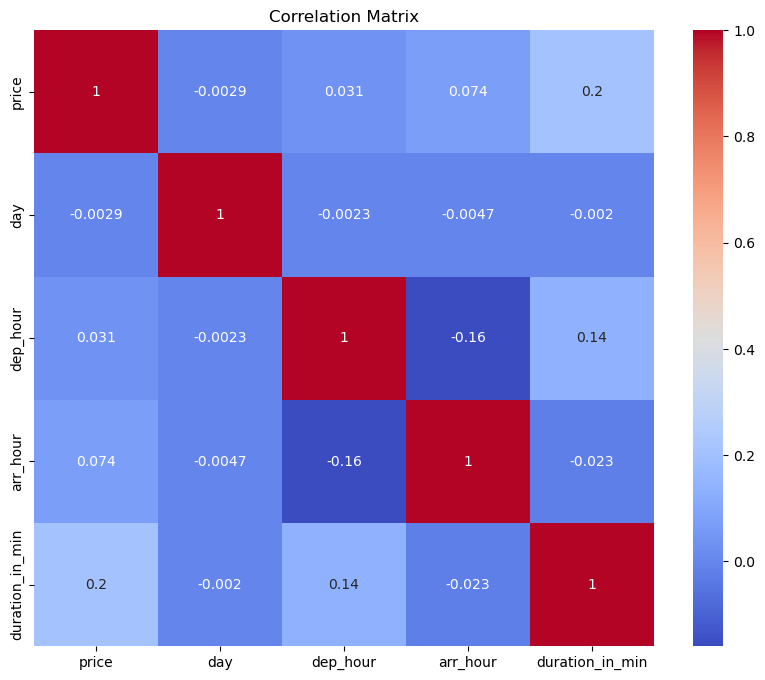

In [22]:
##visualise the correlation matrix
plt.figure(figsize=(10,8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()

In [23]:
corr_with_price = corr_matrix['price'].sort_values(ascending=False)

print(corr_with_price)

price              1.000000
duration_in_min    0.203978
arr_hour           0.074021
dep_hour           0.031355
day               -0.002922
Name: price, dtype: float64


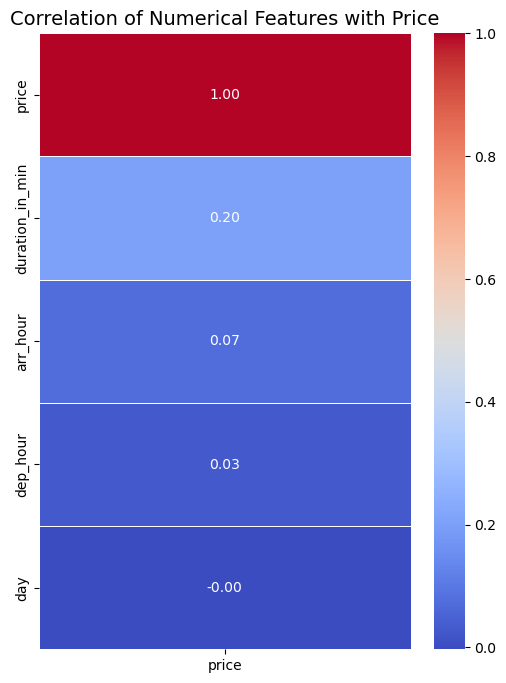

In [ ]:
# Select only numerical columns
numerical_features = df.select_dtypes(include=['int64', 'float64'])

# Correlation with target variable
corr_with_price = numerical_features.corr()[['price']].sort_values(by='price', ascending=False)

# Plot heatmap
plt.figure(figsize=(6, 8))
sns.heatmap(
    corr_with_price,
    annot=True,
    cmap='coolwarm',
    fmt='.2f',
    linewidths=0.5
)

plt.title("Correlation of Numerical Features with Price", fontsize=14)
plt.show()

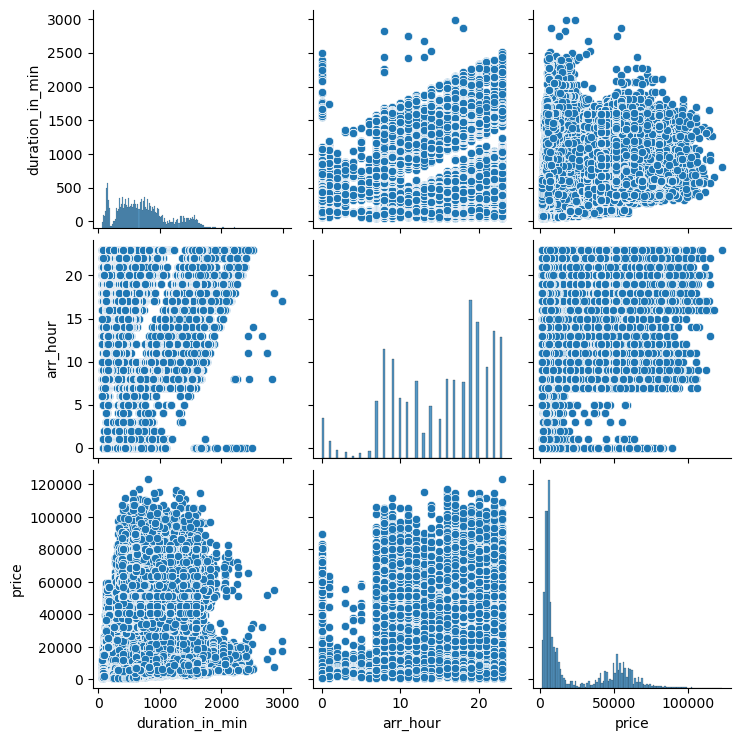

In [41]:


sns.pairplot(
    df[['duration_in_min', 'arr_hour', 'price']],
    diag_kind='hist'
)

plt.show()

In [18]:
df_encoded = pd.get_dummies(df, drop_first=True)

In [19]:
df_encoded

,price,day,dep_hour,arr_hour,duration_in_min,airline_AirAsia,airline_GO FIRST,airline_Indigo,airline_SpiceJet,airline_StarAir,...,dep_period_Morning,dep_period_Night,arr_period_Early_morning,arr_period_Morning,arr_period_Night,stops_category_Multiple-Stops,stops_category_Non-stop,arr_daytime_category_Night Arrival,dep_daytime_category_Night Departure,month_category_March
0,5953,11,18,21,130,False,False,False,True,False,...,False,False,False,False,True,False,True,True,False,False
1,5953,11,6,8,140,False,False,False,True,False,...,False,False,False,True,False,False,True,False,False,False
2,5956,11,4,6,130,True,False,False,False,False,...,False,False,True,False,False,False,True,False,True,False
3,5955,11,10,12,135,False,False,False,False,False,...,True,False,False,True,False,False,True,False,False,False
4,5955,11,8,11,140,False,False,False,False,False,...,True,False,False,True,False,False,True,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
300252,69265,31,9,19,605,False,False,False,False,False,...,True,False,False,False,True,False,False,True,False,True
300253,77105,31,12,22,625,False,False,False,False,False,...,True,False,False,False,True,False,False,True,False,True
300254,79099,31,7,20,830,False,False,False,False,False,...,True,False,False,False,True,False,False,True,False,True
300255,81585,31,7,17,600,False,False,False,False,False,...,True,False,False,False,False,False,False,False,False,True


## 3.2 Train-Test Split

In [20]:
## Split data into train set and test set
from sklearn.model_selection import train_test_split

X = df_encoded.drop('price', axis=1)
y = df_encoded['price']

test_size=0.3
random_state=2026
X_train, X_test, y_train, y_test = train_test_split(X, 
                                                    y,
                                                    test_size=test_size,
                                                    random_state=random_state)


# 4. Modelling

### 4.2 Train Model

In [21]:
## Initialise and train model
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(
    n_estimators=100,
    criterion='squared_error',
    max_depth=None,
    min_samples_split=2,
    min_samples_leaf=1,
    max_features=1.0,
    bootstrap=True,
    random_state=2026
)

rf.fit(X_train, y_train)


,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

In [22]:
feature_importance = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': rf.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
)

feature_importance

,Feature,Importance
21,class_category_Economy,8.801073e-01
3,duration_in_min,5.109631e-02
0,day,1.011219e-02
10,airline_Vistara,9.263340e-03
61,month_category_March,7.955919e-03
...,...,...
41,route_Kolkata-Bangalore,9.434632e-05
54,arr_period_Early_morning,6.653098e-05
58,stops_category_Non-stop,3.416336e-05
9,airline_Trujet,7.991757e-07


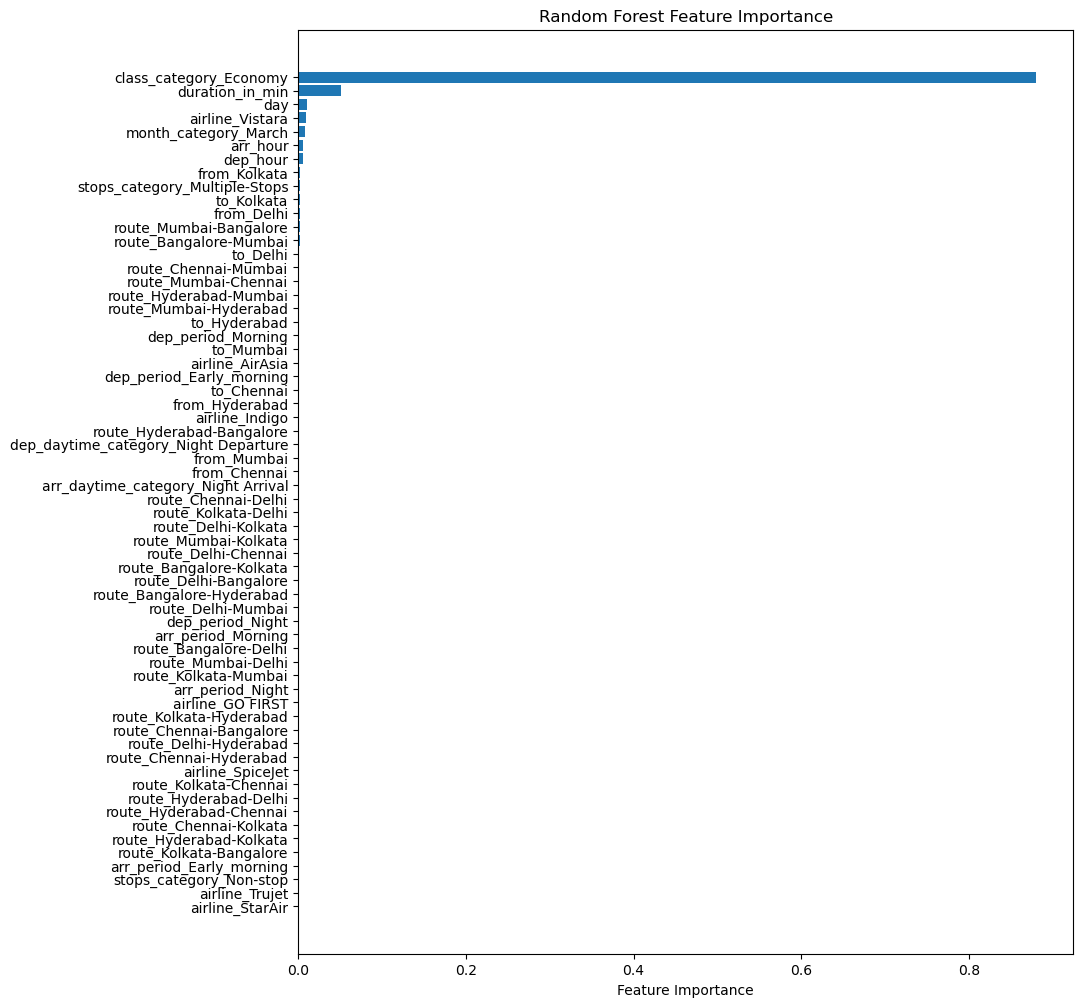

In [23]:
plt.figure(figsize=(10, 12))

plt.barh(
    feature_importance['Feature'],
    feature_importance['Importance']
)

plt.xlabel("Feature Importance")
plt.title("Random Forest Feature Importance")
plt.gca().invert_yaxis()

plt.show()

# 5. Model Evaluation

In [25]:
##checking regression metrics - i will change later to do the calculations that school is doing
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score
import numpy as np

# Make predictions
y_pred_rf = rf.predict(X_test)

# Calculate evaluation metrics
mae = mean_absolute_error(y_test, y_pred_rf)
mse = mean_squared_error(y_test, y_pred_rf)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred_rf)

print(f"MAE : {mae:.2f}")
print(f"MSE : {mse:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"R²  : {r2:.4f}")


MAE : 989.57
MSE : 6206273.27
RMSE: 2491.24
R²  : 0.9879


In [26]:

# New unseen data - predict data 

X_unseen = [['Vistara', 'Delhi', 'Mumbai', 'Economy', 20, 'Delhi-Mumbai',
             10, 12, 'Morning', 'Afternoon', 120,
             'Non-stop', 'Daytime Arrival', 'Daytime Departure', 'March']]

# Convert to OHE Pandas dataframe

col_df_X = df.drop('price', axis=1).columns          # Original feature columns

col_ohe = X.columns.tolist()                         # Encoded feature columns used for training

X_unseen = pd.DataFrame(X_unseen, columns=col_df_X)

X_unseen = pd.get_dummies(X_unseen, drop_first=True)

X_unseen = X_unseen.reindex(columns=col_ohe, fill_value=0)

display(X_unseen)

# Predict

predicted_price = rf.predict(X_unseen)

print(f"Predicted Flight Price: ₹{predicted_price[0]:,.2f}")


,day,dep_hour,arr_hour,duration_in_min,airline_AirAsia,airline_GO FIRST,airline_Indigo,airline_SpiceJet,airline_StarAir,airline_Trujet,...,dep_period_Morning,dep_period_Night,arr_period_Early_morning,arr_period_Morning,arr_period_Night,stops_category_Multiple-Stops,stops_category_Non-stop,arr_daytime_category_Night Arrival,dep_daytime_category_Night Departure,month_category_March
0,20,10,12,120,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


Predicted Flight Price: ₹23,482.34


In [ ]:
## New data

## Predict


## Iterative model development


In [14]:
## Further feature engineering / feature selection

In [27]:

# Create a DataFrame containing feature names and their importance scores
feature_importance = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': rf.feature_importances_
})

# Sort features by importance (highest to lowest)
feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
).reset_index(drop=True)

# Round importance values for better readability
feature_importance['Importance'] = feature_importance['Importance'].round(6)


# Display feature importance table
display(feature_importance)

# Top 10 most important features
display(feature_importance.head(10))

# Bottom 10 least important features
display(feature_importance.tail(10))

,Feature,Importance
0,class_category_Economy,0.880107
1,duration_in_min,0.051096
2,day,0.010112
3,airline_Vistara,0.009263
4,month_category_March,0.007956
...,...,...
57,route_Kolkata-Bangalore,0.000094
58,arr_period_Early_morning,0.000067
59,stops_category_Non-stop,0.000034
60,airline_Trujet,0.000001


,Feature,Importance
0,class_category_Economy,0.880107
1,duration_in_min,0.051096
2,day,0.010112
3,airline_Vistara,0.009263
4,month_category_March,0.007956
5,arr_hour,0.006228
6,dep_hour,0.005763
7,from_Kolkata,0.002249
8,stops_category_Multiple-Stops,0.001819
9,to_Kolkata,0.001787


,Feature,Importance
52,route_Kolkata-Chennai,0.000163
53,route_Hyderabad-Delhi,0.000134
54,route_Hyderabad-Chennai,0.000124
55,route_Chennai-Kolkata,0.000119
56,route_Hyderabad-Kolkata,0.000101
57,route_Kolkata-Bangalore,0.000094
58,arr_period_Early_morning,0.000067
59,stops_category_Non-stop,0.000034
60,airline_Trujet,0.000001
61,airline_StarAir,0.000001


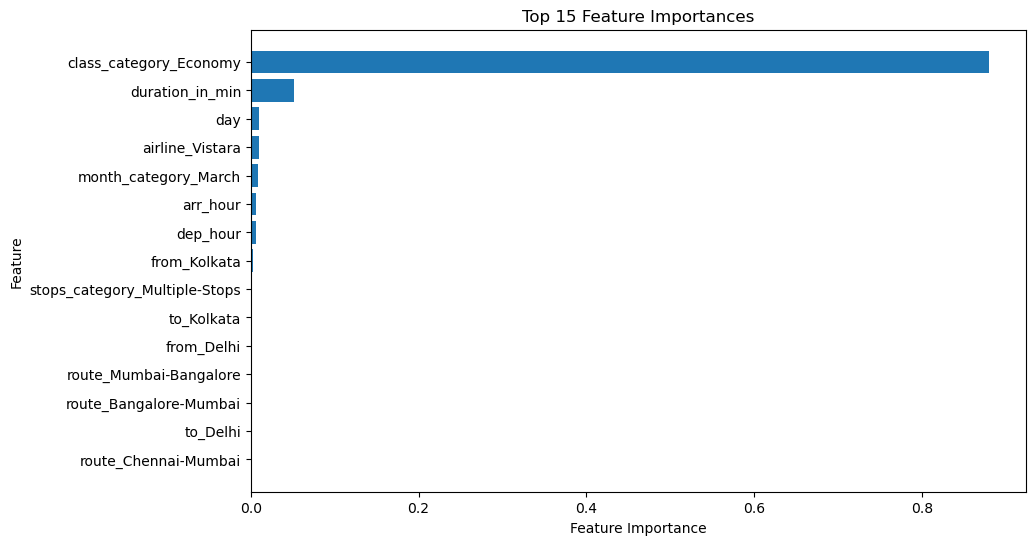

In [28]:
##visualise feature importance
import matplotlib.pyplot as plt

top_features = feature_importance.head(15)

plt.figure(figsize=(10,6))
plt.barh(top_features['Feature'], top_features['Importance'])
plt.xlabel('Feature Importance')
plt.ylabel('Feature')
plt.title('Top 15 Feature Importances')
plt.gca().invert_yaxis()
plt.show()


In [29]:
##outlier detection & analysis
##Features selected for outlier analysis

outlier_features = [
    'price',
    'duration_in_min',
    'day',
    'dep_hour',
    'arr_hour'
]


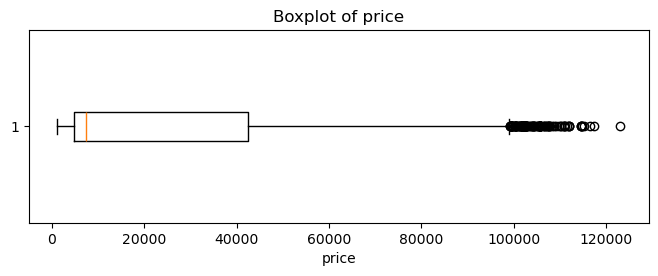

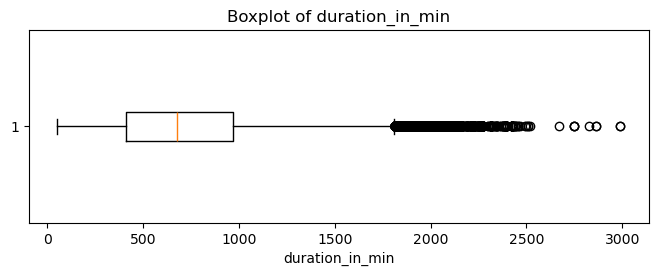

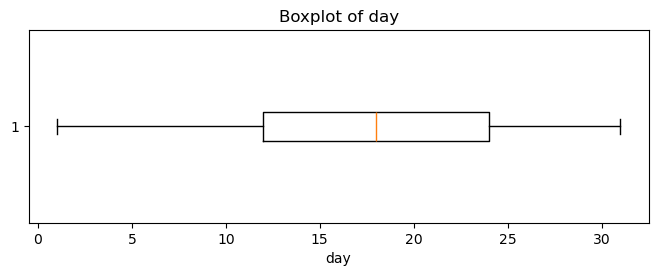

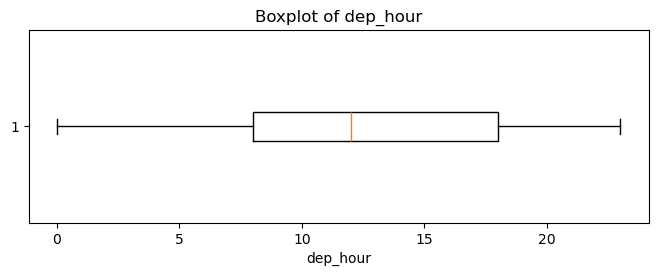

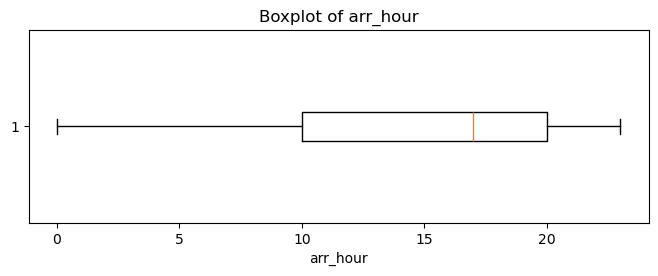

In [30]:
##visualise using boxplots
# Create boxplots for each selected feature
for feature in outlier_features:
    plt.figure(figsize=(8, 2.5))
    plt.boxplot(df_encoded[feature], vert=False)
    plt.title(f'Boxplot of {feature}')
    plt.xlabel(feature)
    plt.show()

In [31]:
## Outlier Detection using the IQR Method

outlier_summary = []

for feature in outlier_features:

    Q1 = df_encoded[feature].quantile(0.25)
    Q3 = df_encoded[feature].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - (1.5 * IQR)
    upper_bound = Q3 + (1.5 * IQR)

    outliers = df_encoded[
        (df_encoded[feature] < lower_bound) |
        (df_encoded[feature] > upper_bound)
    ]

    outlier_summary.append({
        'Feature': feature,
        'Q1': round(Q1, 2),
        'Q3': round(Q3, 2),
        'IQR': round(IQR, 2),
        'Lower Bound': round(lower_bound, 2),
        'Upper Bound': round(upper_bound, 2),
        'No. of Outliers': len(outliers),
        'Percentage (%)': round((len(outliers) / len(df_encoded)) * 100, 2)
    })

outlier_summary = pd.DataFrame(outlier_summary)

display(outlier_summary)

,Feature,Q1,Q3,IQR,Lower Bound,Upper Bound,No. of Outliers,Percentage (%)
0,price,4783.0,42521.0,37738.0,-51824.0,99128.0,123,0.04
1,duration_in_min,410.0,970.0,560.0,-430.0,1810.0,2110,0.70
2,day,12.0,24.0,12.0,-6.0,42.0,0,0.00
3,dep_hour,8.0,18.0,10.0,-7.0,33.0,0,0.00
4,arr_hour,10.0,20.0,10.0,-5.0,35.0,0,0.00


In [33]:
price_upper = 99128

price_outliers = df_encoded[df_encoded['price'] > price_upper]

print("Number of Price Outliers:", len(price_outliers))
price_outliers.head(20)

Number of Price Outliers: 123


,price,day,dep_hour,arr_hour,duration_in_min,airline_AirAsia,airline_GO FIRST,airline_Indigo,airline_SpiceJet,airline_StarAir,...,dep_period_Morning,dep_period_Night,arr_period_Early_morning,arr_period_Morning,arr_period_Night,stops_category_Multiple-Stops,stops_category_Non-stop,arr_daytime_category_Night Arrival,dep_daytime_category_Night Departure,month_category_March
215962,114434,11,19,16,1265,False,False,False,False,False,...,False,True,False,False,False,True,False,False,True,False
215963,116562,11,19,16,1265,False,False,False,False,False,...,False,True,False,False,False,True,False,False,True,False
216129,100395,14,16,9,1055,False,False,False,False,False,...,False,False,False,True,False,True,False,False,False,False
216198,99129,15,10,16,390,False,False,False,False,False,...,True,False,False,False,False,False,False,False,False,False
216199,101369,15,8,16,480,False,False,False,False,False,...,True,False,False,False,False,False,False,False,False,False
216200,117307,15,5,16,655,False,False,False,False,False,...,False,False,False,False,False,True,False,False,True,False
216271,105961,16,9,16,440,False,False,False,False,False,...,True,False,False,False,False,False,False,False,False,False
216411,102114,18,5,16,655,False,False,False,False,False,...,False,False,False,False,False,True,False,False,True,False
216412,102114,18,5,19,840,False,False,False,False,False,...,False,False,False,False,True,True,False,True,True,False
216544,102114,20,5,16,655,False,False,False,False,False,...,False,False,False,False,False,True,False,False,True,False


In [34]:
duration_upper = 1810

duration_outliers = df_encoded[df_encoded['duration_in_min'] > duration_upper]

print("Number of Duration Outliers:", len(duration_outliers))
duration_outliers.head(20)

Number of Duration Outliers: 2110


,price,day,dep_hour,arr_hour,duration_in_min,airline_AirAsia,airline_GO FIRST,airline_Indigo,airline_SpiceJet,airline_StarAir,...,dep_period_Morning,dep_period_Night,arr_period_Early_morning,arr_period_Morning,arr_period_Night,stops_category_Multiple-Stops,stops_category_Non-stop,arr_daytime_category_Night Arrival,dep_daytime_category_Night Departure,month_category_March
10536,12222,14,13,20,1875,False,False,False,False,False,...,False,False,False,False,True,True,False,True,False,False
10537,12222,14,13,22,1990,False,False,False,False,False,...,False,False,False,False,True,True,False,True,False,False
10542,12321,14,5,18,2215,False,False,False,False,False,...,False,False,False,False,False,True,False,False,True,False
10893,12222,16,13,20,1875,False,False,False,False,False,...,False,False,False,False,True,True,False,True,False,False
10894,12222,16,13,22,1990,False,False,False,False,False,...,False,False,False,False,True,True,False,True,False,False
11074,12401,17,13,20,1875,False,False,False,False,False,...,False,False,False,False,True,True,False,True,False,False
11075,12401,17,13,22,1990,False,False,False,False,False,...,False,False,False,False,True,True,False,True,False,False
11430,14819,19,13,20,1875,False,False,False,False,False,...,False,False,False,False,True,True,False,True,False,False
11431,14819,19,13,22,1990,False,False,False,False,False,...,False,False,False,False,True,True,False,True,False,False
11614,13927,20,13,20,1875,False,False,False,False,False,...,False,False,False,False,True,True,False,True,False,False


In [36]:
price_outliers[['price', 'duration_in_min']].describe()

,price,duration_in_min
count,123.000000,123.000000
mean,104639.130081,864.186992
std,4717.170750,323.311740
min,99129.000000,355.000000
25%,101453.500000,642.500000
50%,102648.000000,800.000000
75%,106753.000000,1027.500000
max,123071.000000,1690.000000


In [40]:
print(price_outliers.shape)

(123, 63)


In [41]:
price_outliers[['price', 'duration_in_min']].sort_values(
    by='price',
    ascending=False
).head(10)

,price,duration_in_min
261481,123071,810
216200,117307,655
215963,116562,1265
277449,115211,985
271103,114705,570
290672,114704,905
230196,114523,1350
219287,114507,1645
215962,114434,1265
241652,111964,1310


In [37]:
duration_outliers[['price', 'duration_in_min']].describe()

,price,duration_in_min
count,2110.000000,2110.000000
mean,16956.301896,1990.651659
std,16854.197441,158.107029
min,4363.000000,1815.000000
25%,7490.000000,1870.000000
50%,11865.000000,1950.000000
75%,15372.500000,2060.000000
max,96617.000000,2990.000000


In [42]:
print(duration_outliers.shape)

(2110, 63)


In [43]:
duration_outliers[['price', 'duration_in_min']].sort_values(
    by='duration_in_min',
    ascending=False
).head(10)

,price,duration_in_min
193993,23891,2990
194463,17538,2990
119559,7461,2865
261256,55122,2865
194030,17223,2825
194245,12813,2750
194754,12813,2750
293710,51928,2750
197912,32439,2670
170857,33853,2520


In [38]:
price_outliers.filter(like='class_category').sum()

class_category_Economy    0
dtype: int64

In [39]:
duration_outliers.filter(like='stops_category').sum()

stops_category_Multiple-Stops    820
stops_category_Non-stop            0
dtype: int64

In [53]:
# ------------------------------------------
# Feature Selection - Iteration 1
# ------------------------------------------

# Remove the two least important airline features
df_fs1 = df_encoded.drop(
    columns=[
        'airline_Trujet',
        'airline_StarAir'
    ]
)

print(df_fs1.shape)

(299995, 61)


In [54]:
##split the dataset
from sklearn.model_selection import train_test_split

X = df_fs1.drop('price', axis=1)
y = df_fs1['price']

X_train_fs1, X_test_fs1, y_train_fs1, y_test_fs1 = train_test_split(
    X,
    y,
    test_size=0.3,
    random_state=2026
)

In [55]:
##train the model
from sklearn.ensemble import RandomForestRegressor

rf_fs1 = RandomForestRegressor(
    n_estimators=100,
    criterion='squared_error',
    max_depth=None,
    min_samples_split=2,
    min_samples_leaf=1,
    max_features=1.0,
    bootstrap=True,
    random_state=2026
)

rf_fs1.fit(X_train_fs1, y_train_fs1)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

In [57]:
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score
import numpy as np

# ------------------------------------------
# Feature Selection - Iteration 1 Evaluation
# ------------------------------------------

# Make predictions
y_pred_fs1 = rf_fs1.predict(X_test_fs1)

# Calculate evaluation metrics
mae_fs1 = mean_absolute_error(y_test_fs1, y_pred_fs1)
mse_fs1 = mean_squared_error(y_test_fs1, y_pred_fs1)
rmse_fs1 = np.sqrt(mse_fs1)
r2_fs1 = r2_score(y_test_fs1, y_pred_fs1)

# Display evaluation metrics
print(f"MAE : {mae_fs1:.2f}")
print(f"MSE : {mse_fs1:.2f}")
print(f"RMSE: {rmse_fs1:.2f}")
print(f"R²  : {r2_fs1:.4f}")

MAE : 989.42
MSE : 6204086.36
RMSE: 2490.80
R²  : 0.9879


In [58]:
comparison_fs1 = pd.DataFrame({
    'Metric': ['MAE', 'MSE', 'RMSE', 'R²'],
    'Baseline': [989.57, 6206273.27, 2491.24, 0.9879],
    'Iteration 1': [mae_fs1, mse_fs1, rmse_fs1, r2_fs1]
})

comparison_fs1

,Metric,Baseline,Iteration 1
0,MAE,9.895700e+02,9.894240e+02
1,MSE,6.206273e+06,6.204086e+06
2,RMSE,2.491240e+03,2.490800e+03
3,R²,9.879000e-01,9.879103e-01


In [59]:
print(df_fs1.columns.tolist())

['price', 'day', 'dep_hour', 'arr_hour', 'duration_in_min', 'airline_AirAsia', 'airline_GO FIRST', 'airline_Indigo', 'airline_SpiceJet', 'airline_Vistara', 'from_Chennai', 'from_Delhi', 'from_Hyderabad', 'from_Kolkata', 'from_Mumbai', 'to_Chennai', 'to_Delhi', 'to_Hyderabad', 'to_Kolkata', 'to_Mumbai', 'class_category_Economy', 'route_Bangalore-Delhi', 'route_Bangalore-Hyderabad', 'route_Bangalore-Kolkata', 'route_Bangalore-Mumbai', 'route_Chennai-Bangalore', 'route_Chennai-Delhi', 'route_Chennai-Hyderabad', 'route_Chennai-Kolkata', 'route_Chennai-Mumbai', 'route_Delhi-Bangalore', 'route_Delhi-Chennai', 'route_Delhi-Hyderabad', 'route_Delhi-Kolkata', 'route_Delhi-Mumbai', 'route_Hyderabad-Bangalore', 'route_Hyderabad-Chennai', 'route_Hyderabad-Delhi', 'route_Hyderabad-Kolkata', 'route_Hyderabad-Mumbai', 'route_Kolkata-Bangalore', 'route_Kolkata-Chennai', 'route_Kolkata-Delhi', 'route_Kolkata-Hyderabad', 'route_Kolkata-Mumbai', 'route_Mumbai-Bangalore', 'route_Mumbai-Chennai', 'route_Mu

In [ ]:
##EXPLAIN WHY THE FS2 EXPERIMENT --> DIDNT WORK

In [ ]:
##EXPLAIN WHY THE FS3 EXPERIMENT --> REMOVAL OF DURATION OUTLIERS --> DIDNT WORK 

In [ ]:
##feature engineering 

In [63]:
# Create a copy of the accepted dataset
df_fs4 = df_fs1.copy()

In [64]:
# Cyclical encoding for departure hour
df_fs4['dep_hour_sin'] = np.sin(2 * np.pi * df_fs4['dep_hour'] / 24)
df_fs4['dep_hour_cos'] = np.cos(2 * np.pi * df_fs4['dep_hour'] / 24)

# Cyclical encoding for arrival hour
df_fs4['arr_hour_sin'] = np.sin(2 * np.pi * df_fs4['arr_hour'] / 24)
df_fs4['arr_hour_cos'] = np.cos(2 * np.pi * df_fs4['arr_hour'] / 24)

In [65]:
X = df_fs4.drop('price', axis=1)
y = df_fs4['price']

In [66]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.3,
    random_state=2026
)

In [67]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(
    n_estimators=100,
    criterion='squared_error',
    max_depth=None,
    min_samples_split=2,
    min_samples_leaf=1,
    max_features=1.0,
    bootstrap=True,
    random_state=2026
)

rf.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

In [69]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

y_pred = rf.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("=== Experiment 4: Cyclical Time Features ===")
print(f"MAE : {mae:.2f}")
print(f"MSE : {mse:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"R²  : {r2:.6f}")

=== Experiment 4: Cyclical Time Features ===
MAE : 979.75
MSE : 6182943.86
RMSE: 2486.55
R²  : 0.987951


In [71]:
comparison_fs4 = pd.DataFrame({
    'Metric': ['MAE', 'MSE', 'RMSE', 'R²'],
    'Experiment 1 (Accepted)': [
        989.42,
        6204086,
        2490.80,
        0.987910
    ],
    'Experiment 4 (Feature Engineering)': [
        mae,
        mse,
        rmse,
        r2
    ]
})

comparison_fs4

,Metric,Experiment 1 (Accepted),Experiment 4 (Feature Engineering)
0,MAE,9.894200e+02,9.797481e+02
1,MSE,6.204086e+06,6.182944e+06
2,RMSE,2.490800e+03,2.486553e+03
3,R²,9.879100e-01,9.879515e-01


In [ ]:
##EXPLAIN WHY FS4 IS SUCCESSFUL - JUSTIFICATION ON WHY YOU DID IT AND WHY AND HOW ITS SUCCESSFUL

In [ ]:
##DATA STRUCTURE INSPECTION

In [ ]:
##MODEL COMPARISON

In [ ]:
##LINEAR REGRESSION - FS1
from sklearn.linear_model import LinearRegression

lr = LinearRegression()

lr.fit(X_train_fs1, y_train_fs1)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [30]:
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score
import numpy as np

# Make predictions
y_pred_lr = lr.predict(X_test_fs1)

# Calculate evaluation metrics
mae_lr = mean_absolute_error(y_test_fs1, y_pred_lr)
mse_lr = mean_squared_error(y_test_fs1, y_pred_lr)
rmse_lr = np.sqrt(mse_lr)
r2_lr = r2_score(y_test_fs1, y_pred_lr)

print(f"MAE : {mae_lr:.2f}")
print(f"MSE : {mse_lr:.2f}")
print(f"RMSE: {rmse_lr:.2f}")
print(f"R²  : {r2_lr:.4f}")

MAE : 4520.54
MSE : 45174401.55
RMSE: 6721.19
R²  : 0.9120


In [ ]:
##DECISION TREE REGRESSOR - FS1
from sklearn.tree import DecisionTreeRegressor

# Initialise the model
dt = DecisionTreeRegressor(
    criterion='squared_error',
    random_state=2026
)

# Train the model
dt.fit(X_train_fs1, y_train_fs1)

,"criterion criterion: {""squared_error"", ""friedman_mse"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in the half mean Poisson deviance to find splits... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 0.24 Poisson deviance criterion.",'squared_error'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.For an example of how ``max_depth`` influences the model, see:ref:`sphx_glr_auto_examples_tree_plot_tree_regression.py`.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",2026
,"max

In [32]:
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score
import numpy as np

# Make predictions
y_pred_dt = dt.predict(X_test_fs1)

# Calculate evaluation metrics
mae_dt = mean_absolute_error(y_test_fs1, y_pred_dt)
mse_dt = mean_squared_error(y_test_fs1, y_pred_dt)
rmse_dt = np.sqrt(mse_dt)
r2_dt = r2_score(y_test_fs1, y_pred_dt)

print(f"MAE : {mae_dt:.2f}")
print(f"MSE : {mse_dt:.2f}")
print(f"RMSE: {rmse_dt:.2f}")
print(f"R²  : {r2_dt:.4f}")

MAE : 1041.30
MSE : 10233900.86
RMSE: 3199.05
R²  : 0.9801


In [ ]:
##GRADIET BOOSTING REGRESSOR -FS1
from sklearn.ensemble import GradientBoostingRegressor

# Initialise the model
gbr = GradientBoostingRegressor(
    loss='squared_error',
    learning_rate=0.1,
    n_estimators=100,
    criterion='friedman_mse',
    random_state=2026
)

# Train the model
gbr.fit(X_train_fs1, y_train_fs1)

,"loss loss: {'squared_error', 'absolute_error', 'huber', 'quantile'}, default='squared_error'Loss function to be optimized. 'squared_error' refers to the squarederror for regression. 'absolute_error' refers to the absolute error ofregression and is a robust loss function. 'huber' is acombination of the two. 'quantile' allows quantile regression (use`alpha` to specify the quantile).See:ref:`sphx_glr_auto_examples_ensemble_plot_gradient_boosting_quantile.py`for an example that demonstrates quantile regression for creatingprediction intervals with `loss='quantile'`.",'squared_error'
,"learning_rate learning_rate: float, default=0.1Learning rate shrinks the contribution of each tree by `learning_rate`.There is a trade-off between learning_rate and n_estimators.Values must be in the range `[0.0, inf)`.",0.1
,"n_estimators n_estimators: int, default=100The number of boosting stages to perform. Gradient boostingis fairly robust to over-fitting so a large number usuallyresults in better performance.Values must be in the range `[1, inf)`.",100
,"subsample subsample: float, default=1.0The fraction of samples to be used for fitting the individual baselearners. If smaller than 1.0 this results in Stochastic GradientBoosting. `subsample` interacts with the parameter `n_estimators`.Choosing `subsample < 1.0` leads to a reduction of varianceand an increase in bias.Values must be in the range `(0.0, 1.0]`.",1.0
,"criterion criterion: {'friedman_mse', 'squared_error'}, default='friedman_mse'The function to measure the quality of a split. Supported criteria are""friedman_mse"" for the mean squared error with improvement score byFriedman, ""squared_error"" for mean squared error. The default value of""friedman_mse"" is generally the best as it can provide a betterapproximation in some cases... versionadded:: 0.18",'friedman_mse'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, values must be in the range `[2, inf)`.- If float, values must be in the range `(0.0, 1.0]` and `min_samples_split` will be `ceil(min_samples_split * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, values must be in the range `[1, inf)`.- If float, values must be in the range `(0.0, 1.0)` and `min_samples_leaf` will be `ceil(min_samples_leaf * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.Values must be in the range `[0.0, 0.5]`.",0.0
,"max_depth max_depth: int or None, default=3Maximum depth of the individual regression estimators. The maximumdepth limits the number of nodes in the tree. Tune this parameterfor best performance; the best value depends on the interactionof the input variables. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.If int, values must be in the range `[1, inf)`.",3
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.Values must be in the range `[0.0, inf)`.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft 

In [34]:
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score
import numpy as np

# Make predictions
y_pred_gbr = gbr.predict(X_test_fs1)

# Calculate evaluation metrics
mae_gbr = mean_absolute_error(y_test_fs1, y_pred_gbr)
mse_gbr = mean_squared_error(y_test_fs1, y_pred_gbr)
rmse_gbr = np.sqrt(mse_gbr)
r2_gbr = r2_score(y_test_fs1, y_pred_gbr)

print(f"MAE : {mae_gbr:.2f}")
print(f"MSE : {mse_gbr:.2f}")
print(f"RMSE: {rmse_gbr:.2f}")
print(f"R²  : {r2_gbr:.4f}")

MAE : 2907.49
MSE : 23792867.50
RMSE: 4877.79
R²  : 0.9536


In [35]:
##FINAL COMPARISON TABLE
comparison_models = pd.DataFrame({
    'Model': [
        'Linear Regression',
        'Decision Tree',
        'Random Forest',
        'Gradient Boosting'
    ],
    'MAE': [
        mae_lr,
        mae_dt,
        mae_fs1,
        mae_gbr
    ],
    'MSE': [
        mse_lr,
        mse_dt,
        mse_fs1,
        mse_gbr
    ],
    'RMSE': [
        rmse_lr,
        rmse_dt,
        rmse_fs1,
        rmse_gbr
    ],
    'R²': [
        r2_lr,
        r2_dt,
        r2_fs1,
        r2_gbr
    ]
})

##comparison_models
comparison_models = comparison_models.sort_values(
    by='R²',
    ascending=False
).reset_index(drop=True)

comparison_models

,Model,MAE,MSE,RMSE,R²
0,Random Forest,989.424024,6.204086e+06,2490.800345,0.987910
1,Decision Tree,1041.303422,1.023390e+07,3199.046867,0.980058
2,Gradient Boosting,2907.486637,2.379287e+07,4877.793302,0.953636
3,Linear Regression,4520.542866,4.517440e+07,6721.190486,0.911970


In [ ]:
##LINEAR REGRESSION - FS4